# Variant effect size vs. allele frequency

How does NGN2 lentiMPRA variant effect size relate to gnomAD allele frequency (AF)?
Covers, side by side on the full variant set and on an Enformer-prioritization-bias-free
"random + common" subset throughout (rare/singleton variants were partly selected by an
Enformer-based prioritization step, so any AF trend needs to be checked against a
selection-bias-free subset before it can be trusted):
  1. Fraction of significant / large-effect variants per AF category
  2. Direction of effect (activating vs. repressing) vs. AF category Wilson-CI
     fraction-activating plot, then the more rigorous Cochran-Armitage trend test +
     logistic-regression odds ratio
  3. Effect *magnitude* vs. log10(AF): per-group linear fits, a full-spectrum fit and a
     natural-cubic-spline robustness check, after deduplicating strand-pair/overlapping
     cCRE variants (Extended Data Fig. 4 candidate)
  4. Simpson's-paradox explainer for why a naive full-spectrum fit and the within-group
     fits disagree

Input:
  ../modeling/data/2605_NGN2_variants_with_model_predictions_cadd16_cadd17_alphaGenome_encoder_chrombpnet.tsv.gz
  (gnomAD-annotated NGN2 variant effects; the Enformer prioritization class per variant
  is corrected/re-derived from the per-chromosome Enformer files below and merged in)

Outputs (writing=False by default; set True to regenerate):
  figures under .../09_mpra_manuscript/figures/raw/variant_effect_allele_frequency/
  corrected variant table (optional, writing=True) at .../variant_effects/
  2604_variant_effects_with_gnomad_tested_updated_enformer_random.tsv.gz

In [ ]:
import os
import sys
from os import listdir

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import fisher_exact, chi2_contingency
from patsy import dmatrix, build_design_matrices

sys.path.append("../00_helpful_functions")
import helpful_functions as hf

significant_threshold = 0.1
fontsize_ticks = 12
fontsize_label = 14
chosen_palette = "viridis"
# AF category order used for pd.Categorical dtype / most bar plots
chosen_order = ["very common", "common", "rare", "singleton"]
# same 4 categories, opposite order used for scatter color assignment / QQ-style plots
category_order = ["singleton", "rare", "common", "very common"]

writing = False  # set True to (re)write figures to base_figure_dir
base_figure_dir = "data/"

## Load variant effect table and correct the Enformer prioritization class

The per-variant Enformer prioritization class recorded in the main table can disagree
with the per-chromosome Enformer output files (a variant tested more than once can carry
more than one class); this re-derives `enformer_class`/`enformer_classes_list` from the
per-chromosome files and merges the corrected values back in.

In [ ]:
tested_variants_path = "..//modeling/data/2605_NGN2_variants_with_model_predictions_cadd16_cadd17_alphaGenome_encoder_chrombpnet.tsv.gz"


def load_variant_effect_table(path):
    """Load the variant effect table and eval() any column that holds a list literal."""
    variant_df = pd.read_csv(path, sep="\t")
    example_row = variant_df.iloc[0]
    list_like_cols = [
        col for col in variant_df.columns
        if example_row[col] and isinstance(example_row[col], str) and "[" in example_row[col]
    ]
    for col in list_like_cols:
        variant_df[col] = variant_df[col].apply(hf.safe_eval)
    return variant_df


variant_effect_df_with_gnomad_activity_tested = load_variant_effect_table(tested_variants_path)
print(variant_effect_df_with_gnomad_activity_tested.shape[0])

variant_effect_df_with_gnomad_activity_tested = variant_effect_df_with_gnomad_activity_tested.rename(
    columns={
        "significant_region_NGN2": "NGN2_ref_significant_region",
        "significant_ALT_region_NGN2": "NGN2_alt_significant_region",
        "NGN2_region_logFC": "NGN2_ref_region_logFC",
    }
)
current_column_list = variant_effect_df_with_gnomad_activity_tested.columns.to_list()

38968


In [ ]:
path_to_enformer_files = "data/enformer_prioritization_classes"
all_enformer_prioritization_files = [
    os.path.join(path_to_enformer_files, file)
    for file in listdir(path_to_enformer_files)
    if file.startswith("2604_enformer_prio_class_")
]
all_enformer_prio_df = pd.concat(
    [pd.read_csv(file, sep="\t", low_memory=False) for file in all_enformer_prioritization_files]
)

# a variant tested more than once (e.g. on both strands) can carry more than one class;
# aggregate to the sorted, deduplicated list of classes seen for that variant
resolved_df = (
    all_enformer_prio_df.groupby("chr_pos_ref_alt")["new_enformer_class"]
    .apply(lambda x: sorted(list(x.unique())))
    .reset_index()
    .rename(columns={"new_enformer_class": "enformer_classes_list"})
)
all_enformer_prio_df_deduplicated = pd.merge(
    all_enformer_prio_df, resolved_df, on="chr_pos_ref_alt", how="left"
).drop(columns=["gene_set", "enformer_class", "new_enformer_class"]).drop_duplicates(
    subset="chr_pos_ref_alt", keep="first"
).copy()


def get_enformer_class_from_list(enformer_class_list):
    """Collapse a variant's list of Enformer classes to a single class label."""
    if not isinstance(enformer_class_list, list):
        raise ValueError("enformer_class_list should be a list")
    if len(enformer_class_list) == 0:
        raise ValueError("enformer_class_list is empty, please check the input data.")
    if len(enformer_class_list) == 1:
        return enformer_class_list[0]
    if "enformer_random" in enformer_class_list:
        return "enformer_random"
    raise ValueError("enformer_class_list contains multiple classes, please check the input data.")


all_enformer_prio_df_deduplicated["enformer_class"] = all_enformer_prio_df_deduplicated[
    "enformer_classes_list"
].apply(lambda x: pd.NA if x != x else get_enformer_class_from_list(x))

# replace the table's enformer class columns with the corrected values
variant_effect_df_with_gnomad_activity_tested = variant_effect_df_with_gnomad_activity_tested.drop(
    columns=["enformer_classes_list", "enformer_class"]
).merge(
    all_enformer_prio_df_deduplicated[["chr_pos_ref_alt", "enformer_classes_list", "enformer_class"]],
    on="chr_pos_ref_alt",
    how="left",
)[current_column_list].copy()

corrected_variants_path = "../modeling/data/2604_variant_effects_with_gnomad_tested_updated_enformer_random.tsv.gz"
if writing:
    variant_effect_df_with_gnomad_activity_tested.to_csv(
        corrected_variants_path, sep="\t", index=False, compression="gzip"
    )
    print(f"Written to: {corrected_variants_path}")

## Allele frequency category and the Enformer-bias-free subset

`af_category`: very common (AF >= 5%), common (AF > 1%), rare (AF <= 1%), singleton (AC == 1).
`..._random_or_common`: rare/singleton variants that were randomly sampled (not
Enformer-prioritized) plus all common/very-common variants (which were never
Enformer-prioritized to begin with) the subset in which any AF-effect relationship
can't be an artifact of how rare variants were chosen for testing.

In [4]:
def add_common_ultraRare_singleton_category(af, ac):
    """
    Categorize a variant by gnomAD allele frequency (af) and allele count (ac).
    - 'very common': af >= 0.05
    - 'common': af > 0.01
    - 'rare': af <= 0.01
    - 'singleton': ac == 1
    """
    if pd.isna(af) or pd.isna(ac):
        return "unknown"
    elif ac == 1:
        return "singleton"
    elif af >= 0.05:
        return "very common"
    elif af > 0.01:
        return "common"
    else:
        return "rare"


variant_effect_df_with_gnomad_activity_tested["af_category"] = variant_effect_df_with_gnomad_activity_tested.apply(
    lambda row: add_common_ultraRare_singleton_category(row["gnomad_AF"], row["gnomad_AC"]), axis=1
)
variant_effect_df_with_gnomad_activity_tested["af_category"] = pd.Categorical(
    variant_effect_df_with_gnomad_activity_tested["af_category"], categories=chosen_order, ordered=True
)


def is_enformer_random(enformer_classes):
    return isinstance(enformer_classes, list) and "enformer_random" in enformer_classes


variant_effect_df_with_gnomad_activity_tested_random = variant_effect_df_with_gnomad_activity_tested.loc[
    variant_effect_df_with_gnomad_activity_tested["enformer_classes_list"].apply(is_enformer_random)
].copy()
variant_effect_df_with_gnomad_activity_tested_common = variant_effect_df_with_gnomad_activity_tested.loc[
    variant_effect_df_with_gnomad_activity_tested["enformer_classes_list"].isnull()
].copy()
variant_effect_df_with_gnomad_activity_tested_random_or_common = pd.concat(
    [variant_effect_df_with_gnomad_activity_tested_random, variant_effect_df_with_gnomad_activity_tested_common],
    ignore_index=True,
)

print(
    f"Number of rare/singleton variants that were randomly sampled (not Enformer-prioritized): "
    f"{variant_effect_df_with_gnomad_activity_tested_random_or_common['enformer_classes_list'].notna().sum()}"
)
print(variant_effect_df_with_gnomad_activity_tested_random_or_common["af_category"].value_counts().reindex(chosen_order))

Number of rare/singleton variants that were randomly sampled (not Enformer-prioritized): 3114
af_category
very common    10113
common          8138
rare            1549
singleton       1565
Name: count, dtype: int64


## Overview table: how many variants / significant / in an active region, per AF category

In [5]:
def make_af_overview_table(
    df,
    category_col="af_category",
    sig_col="NGN2_variant_is_significant",
    ref_active_col="NGN2_ref_significant_region",
    alt_active_col="NGN2_alt_significant_region",
    order=None,
):
    df = df.copy()
    df["is_active_region"] = df[ref_active_col].fillna(False) | df[alt_active_col].fillna(False)

    total = df.groupby(category_col).size()
    sig = df[df[sig_col]].groupby(category_col).size()
    active = df[df["is_active_region"]].groupby(category_col).size()
    sig_active = df[df[sig_col] & df["is_active_region"]].groupby(category_col).size()

    summary = pd.DataFrame(
        {"total": total, "significant": sig, "active_region": active, "significant_active_region": sig_active}
    ).fillna(0)
    summary["frac_significant"] = summary["significant"] / summary["total"]
    summary["frac_active"] = summary["active_region"] / summary["total"]
    summary["frac_sig_active"] = summary["significant_active_region"] / summary["total"]
    summary = summary.reset_index()

    if order is not None:
        summary[category_col] = pd.Categorical(summary[category_col], categories=order, ordered=True)
        summary = summary.sort_values(category_col)
    return summary


def format_for_presentation(df):
    df = df.copy()
    for col in ["frac_significant", "frac_active", "frac_sig_active"]:
        df[col] = (df[col] * 100).round(1)
    return df.rename(
        columns={
            "af_category": "AF category", "total": "Total", "significant": "Significant",
            "active_region": "Active region", "significant_active_region": "Sig + Active",
            "frac_significant": "% Significant", "frac_active": "% Active", "frac_sig_active": "% Sig + Active",
        }
    )


summary_all = make_af_overview_table(variant_effect_df_with_gnomad_activity_tested, order=chosen_order)
summary_random = make_af_overview_table(
    variant_effect_df_with_gnomad_activity_tested_random_or_common, order=chosen_order
)
print("All variants:")
print(format_for_presentation(summary_all).to_string(index=False))
print("\nEnformer-bias-free (random + common) subset:")
print(format_for_presentation(summary_random).to_string(index=False))

All variants:
AF category  Total  Significant  Active region  Sig + Active  % Significant  % Active  % Sig + Active
very common  10113          214            837            64            2.1       8.3             0.6
     common   8138          210            668            49            2.6       8.2             0.6
       rare  10331          287            933           125            2.8       9.0             1.2
  singleton  10386          307            968           117            3.0       9.3             1.1

Enformer-bias-free (random + common) subset:
AF category  Total  Significant  Active region  Sig + Active  % Significant  % Active  % Sig + Active
very common  10113          214            837            64            2.1       8.3             0.6
     common   8138          210            668            49            2.6       8.2             0.6
       rare   1549           30            138            11            1.9       8.9             0.7
  singleton   1565    

/tmp/ipykernel_90927/2849644657.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total = df.groupby(category_col).size()
/tmp/ipykernel_90927/2849644657.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig = df[df[sig_col]].groupby(category_col).size()
/tmp/ipykernel_90927/2849644657.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  active = df[df["is_active_region"]].groupby(category_col).size()
/tmp/ipykerne

## Fraction of significant variants per AF category

The manuscript figure: fraction of variants with a significant MPRA effect, by AF
category, with Wilson confidence intervals for the full variant set and again for the
Enformer-bias-free subset, to check the trend isn't an artifact of rare-variant selection.

/tmp/ipykernel_90927/2012030241.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=category_col, y=value_col, order=order, palette=palette, ax=ax, width=0.3)


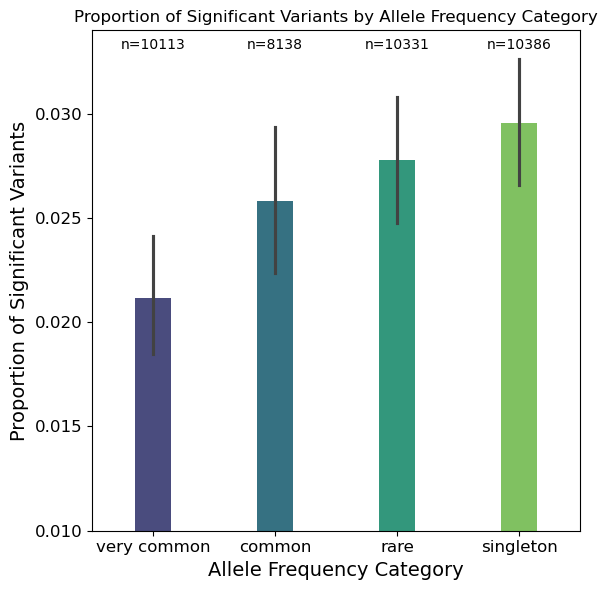

/tmp/ipykernel_90927/2012030241.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=category_col, y=value_col, order=order, palette=palette, ax=ax, width=0.3)


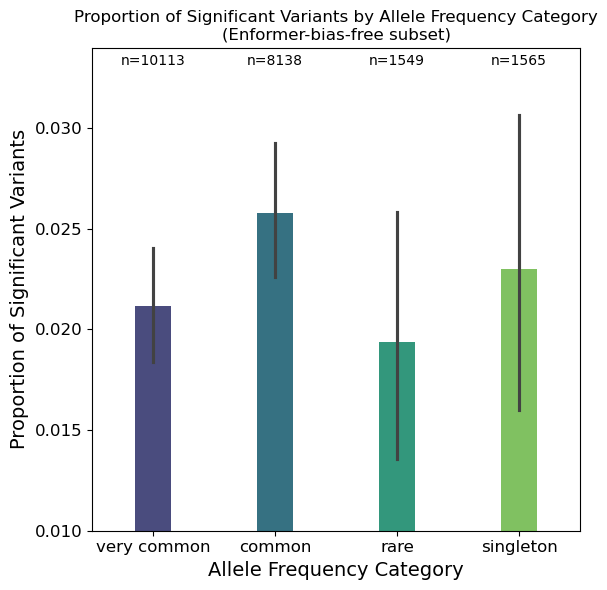

Fraction significant, all variants:
af_category
very common    0.021161
common         0.025805
rare           0.027780
singleton      0.029559
Name: NGN2_variant_is_significant, dtype: float64

Fraction significant, Enformer-bias-free subset:
af_category
very common    0.021161
common         0.025805
rare           0.019367
singleton      0.023003
Name: NGN2_variant_is_significant, dtype: float64


/tmp/ipykernel_90927/2012030241.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(variant_effect_df_with_gnomad_activity_tested.groupby("af_category")["NGN2_variant_is_significant"].mean())
/tmp/ipykernel_90927/2012030241.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variant_effect_df_with_gnomad_activity_tested_random_or_common.groupby("af_category")[


In [6]:
def plot_af_fraction_barplot(
    df,
    category_col="af_category",
    value_col="NGN2_variant_is_significant",
    id_col="ID",
    order=None,
    palette=None,
    title="Proportion of Significant Variants by Allele Frequency Category",
    xlabel="Allele Frequency Category",
    ylabel="Proportion of Significant Variants",
    ylim=None,
    figsize=(6, 6),
    file_name=None,
):
    df = df.copy()
    df[value_col] = df[value_col].astype(float)

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(data=df, x=category_col, y=value_col, order=order, palette=palette, ax=ax, width=0.3)

    if ylim is not None:
        ax.set_ylim(ylim)
    ylim_max = ax.get_ylim()[1]

    for i, category in enumerate(order):
        count = df.loc[df[category_col] == category, id_col].nunique()
        ax.text(i, ylim_max - (ylim_max * 0.03), f"n={count}", ha="center", va="bottom", fontsize=10, color="black")

    ax.set_title(title)
    ax.set_xlabel(xlabel, fontsize=fontsize_label)
    ax.set_ylabel(ylabel, fontsize=fontsize_label)
    ax.tick_params(labelsize=fontsize_ticks)
    plt.tight_layout()

    if writing and file_name:
        out = os.path.join(base_figure_dir, file_name)
        plt.savefig(out + ".png", dpi=300, bbox_inches="tight")
        plt.savefig(out + ".svg", dpi=300, bbox_inches="tight")
    plt.show()


plot_af_fraction_barplot(
    df=variant_effect_df_with_gnomad_activity_tested,
    order=chosen_order,
    palette=chosen_palette,
    ylim=(0.01, 0.034),
    file_name="2605_fraction_significant_by_af_category",
)
plot_af_fraction_barplot(
    df=variant_effect_df_with_gnomad_activity_tested_random_or_common,
    order=chosen_order,
    palette=chosen_palette,
    ylim=(0.01, 0.034),
    title="Proportion of Significant Variants by Allele Frequency Category\n(Enformer-bias-free subset)",
    file_name="2605_fraction_significant_by_af_category_enformer_bias_free",
)

print("Fraction significant, all variants:")
print(variant_effect_df_with_gnomad_activity_tested.groupby("af_category")["NGN2_variant_is_significant"].mean())
print("\nFraction significant, Enformer-bias-free subset:")
print(
    variant_effect_df_with_gnomad_activity_tested_random_or_common.groupby("af_category")[
        "NGN2_variant_is_significant"
    ].mean()
)

## Large-effect variants: are large effects enriched among rare/singleton variants?

"Large effect" = |logFC| > 0.4055 (at least a 20% increase or decrease in activity).
Fisher-exact tests, for both the full set and the Enformer-bias-free subset: rare+singleton
vs. common+very-common, and very-common vs. common alone (to check the trend isn't driven
entirely by the common/very-common split).

In [7]:
large_effect_threshold = 0.4055
variant_effect_df_with_gnomad_activity_tested["large_effect"] = (
    variant_effect_df_with_gnomad_activity_tested["NGN2_variant_abs_logFC"] > large_effect_threshold
)
variant_effect_df_with_gnomad_activity_tested_random_or_common["large_effect"] = (
    variant_effect_df_with_gnomad_activity_tested_random_or_common["NGN2_variant_abs_logFC"] > large_effect_threshold
)


def fisher_common_vs_rare(df, flag_col):
    """Fisher-exact test: {singleton, rare} vs {common, very common}, on a boolean flag column."""
    df = df.copy()
    df["af_group"] = df["af_category"].replace(
        {"singleton": "rare_group", "rare": "rare_group", "common": "common_group", "very common": "common_group"}
    )
    table = pd.crosstab(df["af_group"], df[flag_col])
    oddsratio, pvalue = fisher_exact(table)
    print("Contingency table:\n", table)
    print(f"Odds ratio: {oddsratio:.3f}, p-value: {pvalue:.3e}")
    return table, oddsratio, pvalue


def fisher_very_common_vs_common(df, flag_col):
    """Fisher-exact test: very common vs. common only, on a boolean flag column."""
    df = df.loc[df["af_category"].isin(["common", "very common"])]
    table = pd.crosstab(df["af_category"], df[flag_col]).reindex(["very common", "common"])
    oddsratio, pvalue = fisher_exact(table)
    print("Contingency table:\n", table)
    print(f"Odds ratio: {oddsratio:.3f}, p-value: {pvalue:.3e}")
    return table, oddsratio, pvalue


for flag_col, flag_label in [("large_effect", "large effect"), ("NGN2_variant_is_significant", "significant")]:
    print(f"\n=== {flag_label}: ALL variants, rare-group vs common-group ===")
    fisher_common_vs_rare(variant_effect_df_with_gnomad_activity_tested, flag_col)
    print(f"\n=== {flag_label}: Enformer-bias-free subset, rare-group vs common-group ===")
    fisher_common_vs_rare(variant_effect_df_with_gnomad_activity_tested_random_or_common, flag_col)
    print(f"\n=== {flag_label}: very common vs common ===")
    fisher_very_common_vs_common(variant_effect_df_with_gnomad_activity_tested, flag_col)


=== large effect: ALL variants, rare-group vs common-group ===
Contingency table:
 large_effect  False  True 
af_group                  
common_group  17754    497
rare_group    20040    677
Odds ratio: 1.207, p-value: 1.810e-03

=== large effect: Enformer-bias-free subset, rare-group vs common-group ===
Contingency table:
 large_effect  False  True 
af_group                  
common_group  17754    497
rare_group     3036     78
Odds ratio: 0.918, p-value: 5.104e-01

=== large effect: very common vs common ===
Contingency table:
 large_effect  False  True 
af_category               
very common    9837    276
common         7917    221
Odds ratio: 0.995, p-value: 9.635e-01

=== significant: ALL variants, rare-group vs common-group ===
Contingency table:
 NGN2_variant_is_significant  False  True 
af_group                                 
common_group                 17827    424
rare_group                   20123    594
Odds ratio: 1.241, p-value: 8.258e-04

=== significant: Enformer-

/tmp/ipykernel_90927/517441808.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["af_group"] = df["af_category"].replace(
/tmp/ipykernel_90927/517441808.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["af_group"] = df["af_category"].replace(
/tmp/ipykernel_90927/517441808.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["af_group"] 

Contingency table:
 NGN2_variant_is_significant  False  True 
af_group                                 
common_group                 17827    424
rare_group                    3048     66
Odds ratio: 0.910, p-value: 5.175e-01

=== significant: very common vs common ===
Contingency table:
 NGN2_variant_is_significant  False  True 
af_category                              
very common                   9899    214
common                        7928    210
Odds ratio: 1.225, p-value: 4.259e-02


## Direction of effect vs. AF category

Fraction of variants with an activating effect (vs. repressing), with Wilson confidence
intervals, for variants in active regions and for significant variants, restricted to
the Enformer-bias-free subset (excluding the small number of Enformer-"deleted" calls).

direction  af_category  activating  repressing  total  fraction_activating  \
0          very common         436         401    837             0.520908   
1               common         343         325    668             0.513473   
2                 rare          68          70    138             0.492754   
3            singleton          62          72    134             0.462687   

direction    ci_low   ci_high  
0          0.487046  0.554579  
1          0.475602  0.551190  
2          0.410674  0.575226  
3          0.380483  0.546970  
direction  af_category  activating  repressing  total  fraction_activating  \
0          very common         113         101    214             0.528037   
1               common         126          84    210             0.600000   
2                 rare          15          15     30             0.500000   
3            singleton          16          20     36             0.444444   

direction    ci_low   ci_high  
0          0.461249  0.593

/tmp/ipykernel_90927/1818366192.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("af_category")["direction"].value_counts().unstack(fill_value=0).reset_index()
/tmp/ipykernel_90927/1818366192.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("af_category")["direction"].value_counts().unstack(fill_value=0).reset_index()


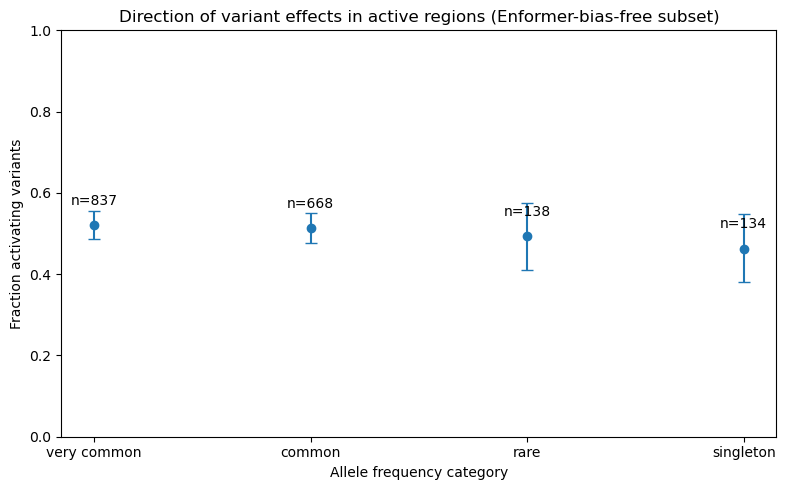

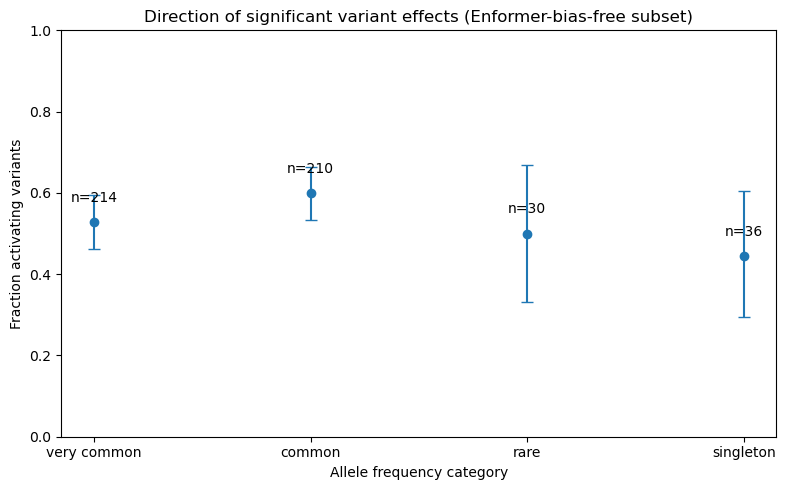

In [8]:
variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted = (
    variant_effect_df_with_gnomad_activity_tested_random_or_common[
        ~variant_effect_df_with_gnomad_activity_tested_random_or_common["enformer_classes_list"]
        .apply(str)
        .str.contains("deleted", regex=False, na=False, case=False)
    ]
)


def classify_effect_direction(row, variant_effect_col="NGN2_variant_logFC"):
    logFC = row[variant_effect_col]
    if logFC > 0:
        return "activating"
    elif logFC < 0:
        return "repressing"
    else:
        return "neutral"


def compute_direction_stats(df):
    """Fraction of activating (vs. repressing) variants per AF category, with Wilson CIs."""
    summary = df.groupby("af_category")["direction"].value_counts().unstack(fill_value=0).reset_index()
    for col in ["activating", "repressing"]:
        if col not in summary.columns:
            summary[col] = 0
    summary["total"] = summary["activating"] + summary["repressing"]
    summary["fraction_activating"] = summary["activating"] / summary["total"]
    ci = summary.apply(
        lambda row: sm.stats.proportion_confint(row["activating"], row["total"], method="wilson"), axis=1
    )
    summary["ci_low"] = ci.apply(lambda c: c[0])
    summary["ci_high"] = ci.apply(lambda c: c[1])
    return summary


def plot_fraction_activating(summary_df, title, order=None):
    df = summary_df.copy()
    if order is not None:
        df["af_category"] = pd.Categorical(df["af_category"], categories=order, ordered=True)
        df = df.sort_values("af_category")

    x = np.arange(len(df))
    plt.figure(figsize=(8, 5))
    plt.errorbar(
        x=x, y=df["fraction_activating"],
        yerr=[df["fraction_activating"] - df["ci_low"], df["ci_high"] - df["fraction_activating"]],
        fmt="o", capsize=4,
    )
    plt.xticks(x, df["af_category"])
    plt.ylabel("Fraction activating variants")
    plt.xlabel("Allele frequency category")
    plt.title(title)
    for i, (_, row) in enumerate(df.iterrows()):
        plt.text(i, row["fraction_activating"] + 0.05, f"n={int(row['total'])}", ha="center")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted["direction"] = (
    variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted.apply(classify_effect_direction, axis=1)
)
variant_active_regions_common_random = variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted.loc[
    variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted["NGN2_ref_significant_region"]
    | variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted["NGN2_alt_significant_region"]
].copy()
significant_variant_common_random = variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted.loc[
    variant_effect_df_with_gnomad_activity_tested_random_or_common_no_deleted["NGN2_variant_is_significant"]
].copy()

summary_active_regions = compute_direction_stats(variant_active_regions_common_random)
summary_significant = compute_direction_stats(significant_variant_common_random)
print(summary_active_regions)
print(summary_significant)

plot_fraction_activating(
    summary_active_regions, "Direction of variant effects in active regions (Enformer-bias-free subset)",
    order=chosen_order,
)
plot_fraction_activating(
    summary_significant, "Direction of significant variant effects (Enformer-bias-free subset)", order=chosen_order,
)

## QC: are duplicated variants (tested on both strands) consistent with each other?

In [9]:
variant_effect_df_with_gnomad_activity_tested_duplicates = variant_effect_df_with_gnomad_activity_tested.loc[
    variant_effect_df_with_gnomad_activity_tested["chr_pos_ref_alt"].duplicated(keep=False)
].copy()
duplicates_sig_ids = variant_effect_df_with_gnomad_activity_tested_duplicates.loc[
    variant_effect_df_with_gnomad_activity_tested_duplicates["NGN2_variant_adj_p-value"] < 0.1
]["chr_pos_ref_alt"].to_list()
filtered_duplicates_sig = variant_effect_df_with_gnomad_activity_tested_duplicates.loc[
    variant_effect_df_with_gnomad_activity_tested_duplicates["chr_pos_ref_alt"].isin(duplicates_sig_ids)
]
print(filtered_duplicates_sig[["chr_pos_ref_alt", "NGN2_variant_adj_p-value", "NGN2_variant_logFC"]].to_string())

       chr_pos_ref_alt  NGN2_variant_adj_p-value  NGN2_variant_logFC
6702     11-679380-A-T              9.363180e-01            0.053298
6703     11-679380-A-T              4.984860e-02            0.480878
6712     11-686714-G-A              9.794046e-01           -0.025813
6713     11-686714-G-A              2.477618e-06           -1.180988
13493  15-78839371-G-T              9.283179e-01           -0.048870
13494  15-78839371-G-T              8.833831e-02           -0.421262
19798  19-49618058-A-G              5.032991e-01            0.344170
19799  19-49618058-A-G              3.737550e-03           -0.516779
28296  4-119106334-G-A              1.124344e-02            0.348608
28297  4-119106334-G-A              6.798693e-16            1.135592
34673  7-151552086-T-G              8.136323e-02            0.647573
34674  7-151552086-T-G              4.851400e-02            0.477379


## Direction of effect vs. AF category Cochran-Armitage trend test + logistic odds ratio

More rigorous version of the plot above: a proper ordered-categories trend test
(Cochran-Armitage) and a logistic-regression odds ratio (rare+singleton vs.
common+very-common) for whether the proportion of activating (vs. repressing)
significant effects changes with AF, on the full variant set.

In [10]:
FDR_THRESHOLD = significant_threshold

df = variant_effect_df_with_gnomad_activity_tested.copy()
df["af_group"] = df["af_category"].apply(
    lambda x: "Rare/Singleton" if x in ["singleton", "rare"] else "Common/Very Common"
)
df_sig = df[df["NGN2_variant_adj_p-value"] < FDR_THRESHOLD].copy()
df_sig["effect_direction"] = np.where(df_sig["NGN2_variant_logFC"] > 0, "activating", "reducing")
category_scores = {"singleton": 1, "rare": 2, "common": 3, "very common": 4}
df_sig["category_score"] = df_sig["af_category"].map(category_scores).astype(int)
df_sig["is_activating"] = (df_sig["effect_direction"] == "activating").astype(int)

print("=== Data Summary ===")
print(f"Total variants: {len(df)}")
print(f"Significant variants: {len(df_sig)} ({100*len(df_sig)/len(df):.1f}%)")
print("\nSignificant by AF group:")
print(df_sig["af_group"].value_counts())
print("\nSignificant by effect direction:")
print(df_sig["effect_direction"].value_counts())

=== Data Summary ===
Total variants: 38968
Significant variants: 1018 (2.6%)

Significant by AF group:
af_group
Rare/Singleton        594
Common/Very Common    424
Name: count, dtype: int64

Significant by effect direction:
effect_direction
activating    605
reducing      413
Name: count, dtype: int64


In [11]:
print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS: Direction by AF Group")
print("=" * 60)

contingency_2x2 = pd.crosstab(df_sig["af_group"], df_sig["effect_direction"], margins=True)
print("\n--- Contingency Table (2x2) ---")
print(contingency_2x2)

proportions_2x2 = pd.crosstab(df_sig["af_group"], df_sig["effect_direction"], normalize="index")
print("\n--- Proportions (row-normalized) ---")
print(proportions_2x2.round(4))

contingency_2x2_no_margins = pd.crosstab(df_sig["af_group"], df_sig["effect_direction"])
chi2, p_chi2, dof, expected = chi2_contingency(contingency_2x2_no_margins)
print("\n--- Chi-square Test (2x2) ---")
print(f"chi2 = {chi2:.3f}, df = {dof}, p = {p_chi2:.4e}")

print("\n" + "-" * 40)
print("--- Contingency Table (4x2: by AF category) ---")
contingency_4x2 = pd.crosstab(df_sig["af_category"], df_sig["effect_direction"], margins=True).reindex(
    category_order + ["All"]
)
print(contingency_4x2)


STATISTICAL ANALYSIS: Direction by AF Group

--- Contingency Table (2x2) ---
effect_direction    activating  reducing   All
af_group                                      
Common/Very Common         239       185   424
Rare/Singleton             366       228   594
All                        605       413  1018

--- Proportions (row-normalized) ---
effect_direction    activating  reducing
af_group                                
Common/Very Common      0.5637    0.4363
Rare/Singleton          0.6162    0.3838

--- Chi-square Test (2x2) ---
chi2 = 2.613, df = 1, p = 1.0600e-01

----------------------------------------
--- Contingency Table (4x2: by AF category) ---
effect_direction  activating  reducing   All
af_category                                 
singleton                193       114   307
rare                     173       114   287
common                   126        84   210
very common              113       101   214
All                      605       413  1018


In [12]:
def cochran_armitage_test(df, success_col, score_col):
    """Cochran-Armitage trend test: does the proportion of successes trend with ordered groups?"""
    df = df.copy()
    df[score_col] = df[score_col].astype(float)
    df[success_col] = df[success_col].astype(float)
    grouped = df.groupby(score_col).agg(n=(success_col, "count"), x=(success_col, "sum")).reset_index()

    N, X = grouped["n"].sum(), grouped["x"].sum()
    p_bar = X / N
    t_scores, n_i, x_i = grouped[score_col].values, grouped["n"].values, grouped["x"].values
    t_bar = np.sum(n_i * t_scores) / N

    numerator = np.sum((t_scores - t_bar) * (x_i - n_i * p_bar))
    denominator = np.sqrt(p_bar * (1 - p_bar) * (np.sum(n_i * t_scores**2) - N * t_bar**2))
    if denominator == 0:
        return np.nan, np.nan

    z_stat = numerator / denominator
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value


print("\n" + "-" * 40)
print("--- Cochran-Armitage Trend Test ---")
z_ca, p_ca = cochran_armitage_test(df_sig, "is_activating", "category_score")
print(f"Z-statistic = {z_ca:.3f}\np-value = {p_ca:.4e}")
print(
    "-> Positive Z: proportion of activating effects INCREASES from rare to common"
    if z_ca > 0
    else "-> Negative Z: proportion of activating effects DECREASES from rare to common"
)

print("\n" + "-" * 40)
print("--- Logistic Regression (Odds Ratio) ---")
df_sig["is_rare"] = (df_sig["af_group"] == "Rare/Singleton").astype(int)
logit_model = sm.Logit(df_sig["is_activating"], sm.add_constant(df_sig["is_rare"])).fit(disp=0)
print(logit_model.summary2().tables[1])

odds_ratio = np.exp(logit_model.params["is_rare"])
or_ci_lower, or_ci_upper = np.exp(logit_model.conf_int().loc["is_rare"])
p_logit = logit_model.pvalues["is_rare"]
print(f"\nOdds Ratio (Rare vs Common): {odds_ratio:.3f}")
print(f"95% CI: [{or_ci_lower:.3f}, {or_ci_upper:.3f}]")
print(f"p-value: {p_logit:.4e}")


----------------------------------------
--- Cochran-Armitage Trend Test ---
Z-statistic = -2.159
p-value = 3.0836e-02
-> Negative Z: proportion of activating effects DECREASES from rare to common

----------------------------------------
--- Logistic Regression (Odds Ratio) ---


            Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const    0.256108  0.097926  2.615318  0.008914  0.064176  0.448039
is_rare  0.217180  0.129258  1.680201  0.092918 -0.036162  0.470522

Odds Ratio (Rare vs Common): 1.243
95% CI: [0.964, 1.601]
p-value: 9.2918e-02


/tmp/ipykernel_90927/2074140943.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(chosen_palette)
/tmp/ipykernel_90927/2074140943.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


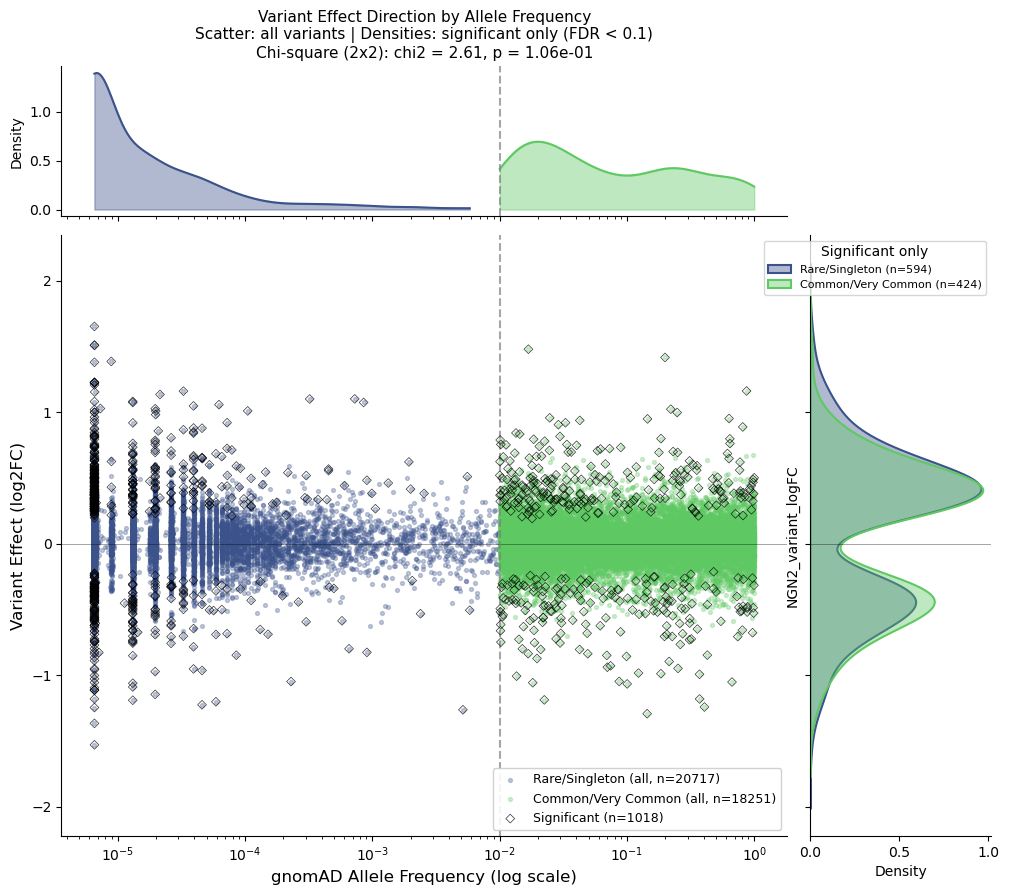


--- Interpretation ---
Chi-square (2x2): chi2 = 2.613, p = 1.0600e-01
Odds Ratio (Rare vs Common being activating): 1.243 [0.964, 1.601]
Cochran-Armitage trend (across 4 categories): Z = -2.159, p = 3.0836e-02
Rare/Singleton: 61.6% activating vs Common/Very Common: 56.4% activating


In [13]:
# Visualization: scatter of ALL variants, densities of SIGNIFICANT variants only.

cmap = plt.cm.get_cmap(chosen_palette)
rare_color, common_color = cmap(0.25), cmap(0.75)

fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
for af_group, color, label in [
    ("Rare/Singleton", rare_color, "Rare/Singleton"),
    ("Common/Very Common", common_color, "Common/Very Common"),
]:
    mask = df["af_group"] == af_group
    ax_main.scatter(
        df.loc[mask, "gnomad_AF"], df.loc[mask, "NGN2_variant_logFC"],
        c=[color], alpha=0.3, s=8, label=f"{label} (all, n={mask.sum()})", rasterized=True,
    )
ax_main.scatter(
    df_sig["gnomad_AF"], df_sig["NGN2_variant_logFC"], facecolors="none", edgecolors="black",
    alpha=0.8, s=20, linewidths=0.5, label=f"Significant (n={len(df_sig)})", rasterized=True, zorder=3, marker="D",
)
ax_main.axhline(y=0, color="black", linestyle="-", linewidth=0.5, alpha=0.5)
ax_main.axvline(x=0.01, color="grey", linestyle="--", linewidth=1.5, alpha=0.7)
ax_main.set_xscale("log")
ax_main.set_xlabel("gnomAD Allele Frequency (log scale)", fontsize=12)
ax_main.set_ylabel("Variant Effect (log2FC)", fontsize=12)
ax_main.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax_main.spines["top"].set_visible(False)
ax_main.spines["right"].set_visible(False)

ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
for af_group, color, label in [
    ("Rare/Singleton", rare_color, "Rare/Singleton"),
    ("Common/Very Common", common_color, "Common/Very Common"),
]:
    subset = df_sig[df_sig["af_group"] == af_group]
    if len(subset) > 10:
        sns.kdeplot(
            y=subset["NGN2_variant_logFC"], ax=ax_right, color=color, fill=True, alpha=0.4, linewidth=1.5,
            label=f"{label} (n={len(subset)})",
        )
ax_right.axhline(y=0, color="black", linestyle="-", linewidth=0.5, alpha=0.5)
ax_right.set_xlabel("Density", fontsize=10)
ax_right.tick_params(labelleft=False)
ax_right.legend(fontsize=8, loc="upper right", title="Significant only")
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)

ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
for af_group, color in [("Rare/Singleton", rare_color), ("Common/Very Common", common_color)]:
    subset = df_sig[df_sig["af_group"] == af_group]
    if len(subset) > 10:
        log_af = np.log10(subset["gnomad_AF"])
        kde = stats.gaussian_kde(log_af)
        x_range = np.linspace(log_af.min(), log_af.max(), 200)
        ax_top.fill_between(10**x_range, kde(x_range), alpha=0.4, color=color)
        ax_top.plot(10**x_range, kde(x_range), color=color, linewidth=1.5)
ax_top.axvline(x=0.01, color="grey", linestyle="--", linewidth=1.5, alpha=0.7)
ax_top.set_ylabel("Density", fontsize=10)
ax_top.tick_params(labelbottom=False)
ax_top.set_title(
    f"Variant Effect Direction by Allele Frequency\n"
    f"Scatter: all variants | Densities: significant only (FDR < {FDR_THRESHOLD})\n"
    f"Chi-square (2x2): chi2 = {chi2:.2f}, p = {p_chi2:.2e}",
    fontsize=11,
)
ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)

fig.add_subplot(gs[0, 1]).axis("off")
plt.tight_layout()
if writing:
    out = os.path.join(base_figure_dir, "direction_analysis_all_scatter_sig_density")
    plt.savefig(out + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(out + ".svg", dpi=300, bbox_inches="tight")
plt.show()

print("\n--- Interpretation ---")
rare_prop_act = proportions_2x2.loc["Rare/Singleton", "activating"]
common_prop_act = proportions_2x2.loc["Common/Very Common", "activating"]
print(f"Chi-square (2x2): chi2 = {chi2:.3f}, p = {p_chi2:.4e}")
print(f"Odds Ratio (Rare vs Common being activating): {odds_ratio:.3f} [{or_ci_lower:.3f}, {or_ci_upper:.3f}]")
print(f"Cochran-Armitage trend (across 4 categories): Z = {z_ca:.3f}, p = {p_ca:.4e}")
print(f"Rare/Singleton: {rare_prop_act:.1%} activating vs Common/Very Common: {common_prop_act:.1%} activating")

## Direction trend within the common variants only (finer AF resolution, no rare/common split)

In [14]:
df_common = variant_effect_df_with_gnomad_activity_tested.copy()
df_common = df_common[df_common["af_category"].isin(["common", "very common"])].copy()
df_common = df_common[df_common["NGN2_variant_adj_p-value"] < FDR_THRESHOLD].copy()
df_common["is_activating"] = (df_common["NGN2_variant_logFC"] > 0).astype(int)

n_bins = 4
df_common["af_bin"] = pd.qcut(df_common["gnomad_AF"], q=n_bins, duplicates="drop")
df_common["af_bin_score"] = pd.factorize(df_common["af_bin"])[0] + 1
print(df_common["af_bin"].value_counts())

contingency = pd.crosstab(df_common["af_bin"], df_common["is_activating"])
contingency.columns = ["reducing", "activating"]
print("\n=== Contingency Table (binned AF, common variants only) ===")
print(contingency)
print("\n=== Proportions ===")
print(contingency.div(contingency.sum(axis=1), axis=0))

z_bin, p_bin = cochran_armitage_test(df_common, "is_activating", "af_bin_score")
print("\n=== Cochran-Armitage Trend Test (within common variants) ===")
print(f"Z = {z_bin:.3f}, p = {p_bin:.4e}")

af_bin
(0.009000000000000001, 0.0199]    106
(0.0199, 0.0514]                  106
(0.0514, 0.249]                   106
(0.249, 0.999]                    106
Name: count, dtype: int64

=== Contingency Table (binned AF, common variants only) ===
                                reducing  activating
af_bin                                              
(0.009000000000000001, 0.0199]        41          65
(0.0199, 0.0514]                      44          62
(0.0514, 0.249]                       54          52
(0.249, 0.999]                        46          60

=== Proportions ===
                                reducing  activating
af_bin                                              
(0.009000000000000001, 0.0199]  0.386792    0.613208
(0.0199, 0.0514]                0.415094    0.584906
(0.0514, 0.249]                 0.509434    0.490566
(0.249, 0.999]                  0.433962    0.566038

=== Cochran-Armitage Trend Test (within common variants) ===
Z = 0.832, p = 4.0536e-01


## Effect magnitude vs. allele frequency (Extended Data Fig. 4 candidate)

Adds, on top of the per-group log10(AF) fits used earlier in this analysis:
  1. Deduplication of strand-pair / overlapping-cCRE duplicate variants (averaged rather
     than counted twice).
  2. Log10(AF) linear fits per group (rare, common), with the dedup applied.
  3. A full-spectrum log10(AF) linear fit as a robustness check, on both the full dataset
     and the Enformer-bias-free subset, with a slope-difference z-test between them.
  4. A natural cubic spline of |log2FC| ~ log10(AF) across the full spectrum, with a
     nested F-test against the linear model, to check for non-monotonic structure beyond
     a linear log-AF trend.

In [ ]:
CATEGORY_ORDER = ["singleton", "rare", "common", "very common"]


def deduplicate_variants(
    df, value_col="NGN2_variant_abs_logFC", signed_col="NGN2_variant_logFC", pval_col="NGN2_variant_adj_p-value"
):
    """
    Variants tested in more than one cCRE (strand pairs or same-strand overlaps) are
    present as separate rows sharing the same genomic variant. Collapse them to one row
    per genomic variant by averaging the MPRA effect, keeping AF/category, and tracking
    how many observations were merged. Dedup key: SPDI (strand-agnostic genomic variant id).
    """
    df = df.copy()
    n_before = len(df)
    agg_dict = {
        value_col: "mean", signed_col: "mean", "gnomad_AF": "first", "af_category": "first",
        "enformer_classes_list": "first", pval_col: "min",
    }
    agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}
    grouped = df.groupby("SPDI", as_index=False).agg(agg_dict)
    grouped["n_instances"] = df.groupby("SPDI").size().reset_index(name="n_instances")["n_instances"].values
    n_after = len(grouped)
    print(
        f"  Dedup: {n_before} rows -> {n_after} unique variants (removed {n_before - n_after} duplicate rows "
        f"from {(grouped['n_instances'] > 1).sum()} duplicated variants)"
    )
    return grouped.drop(columns="SPDI", errors="ignore")


def assign_af_group(af_category):
    if af_category in ["singleton", "rare"]:
        return "rare_group"
    if af_category in ["common", "very common"]:
        return "common_group"
    return "unknown"


print("=" * 60)
print("STEP 1: DEDUPLICATION")
print("=" * 60)
print("Full dataset:")
df_full = deduplicate_variants(variant_effect_df_with_gnomad_activity_tested)
print("Enformer-bias-free (random-or-common) dataset:")
df_random_or_common = deduplicate_variants(variant_effect_df_with_gnomad_activity_tested_random_or_common)
df_full["af_group"] = df_full["af_category"].apply(assign_af_group)
df_random_or_common["af_group"] = df_random_or_common["af_category"].apply(assign_af_group)

STEP 1: DEDUPLICATION
Full dataset:


  Dedup: 38968 rows -> 38684 unique variants (removed 284 duplicate rows from 284 duplicated variants)
Enformer-bias-free (random-or-common) dataset:
  Dedup: 21365 rows -> 21216 unique variants (removed 149 duplicate rows from 149 duplicated variants)


In [ ]:
def fit_group_log10AF(df, af_group, dataset_name):
    """Linear regression of |log2FC| ~ log10(AF) within one AF group (rare_group / common_group)."""
    sub = df[df["af_group"] == af_group].dropna(subset=["gnomad_AF", "NGN2_variant_abs_logFC"])
    sub = sub[sub["gnomad_AF"] > 0].copy()
    if len(sub) < 10:
        return None, None, None
    sub["log10_AF"] = np.log10(sub["gnomad_AF"])
    model = sm.OLS(sub["NGN2_variant_abs_logFC"], sm.add_constant(sub["log10_AF"])).fit()
    slope, intercept, r, p, se = stats.linregress(sub["log10_AF"], sub["NGN2_variant_abs_logFC"])
    ci_lo, ci_hi = model.conf_int().loc["log10_AF"].values
    summary = {
        "dataset": dataset_name, "af_group": af_group, "n_variants": len(sub), "slope": slope,
        "intercept": intercept, "r_squared": r**2, "p_value": p, "std_err": se,
        "slope_ci_lower": ci_lo, "slope_ci_upper": ci_hi,
    }
    return model, summary, sub


print("\n" + "=" * 60)
print("STEP 2: PER-GROUP LINEAR REGRESSION ON log10(AF)")
print("=" * 60)
m_full_rare, s_full_rare, d_full_rare = fit_group_log10AF(df_full, "rare_group", "all_variants")
m_full_common, s_full_common, d_full_common = fit_group_log10AF(df_full, "common_group", "all_variants")
m_rand_rare, s_rand_rare, d_rand_rare = fit_group_log10AF(df_random_or_common, "rare_group", "random_or_common")
m_rand_common, s_rand_common, d_rand_common = fit_group_log10AF(df_random_or_common, "common_group", "random_or_common")
regression_summary = pd.DataFrame([s for s in [s_full_rare, s_full_common, s_rand_rare, s_rand_common] if s is not None])
print(regression_summary.to_string(index=False))

z_rare = (s_full_rare["slope"] - s_rand_rare["slope"]) / np.sqrt(
    s_full_rare["std_err"] ** 2 + s_rand_rare["std_err"] ** 2
)
p_diff_rare = 2 * (1 - stats.norm.cdf(abs(z_rare)))
print(f"\nRare-arm slope-difference z-test (full vs. Enformer-bias-free): z = {z_rare:.3f}, p = {p_diff_rare:.4f}")


STEP 2: PER-GROUP LINEAR REGRESSION ON log10(AF)
         dataset     af_group  n_variants    slope  intercept  r_squared  p_value  std_err  slope_ci_lower  slope_ci_upper
    all_variants   rare_group       20560 0.001396   0.133868   0.000041 0.361251 0.001529       -0.001601        0.004392
    all_variants common_group       18124 0.002536   0.125015   0.000184 0.067789 0.001389       -0.000185        0.005258
random_or_common   rare_group        3092 0.004365   0.142695   0.000515 0.207287 0.003461       -0.002420        0.011150
random_or_common common_group       18124 0.002536   0.125015   0.000184 0.067789 0.001389       -0.000185        0.005258

Rare-arm slope-difference z-test (full vs. Enformer-bias-free): z = -0.785, p = 0.4325


In [ ]:
def fit_fullspectrum_log10AF(df, dataset_name):
    """Linear regression of |log2FC| ~ log10(AF) across the full AF spectrum (robustness check)."""
    sub = df.dropna(subset=["gnomad_AF", "NGN2_variant_abs_logFC"])
    sub = sub[sub["gnomad_AF"] > 0].copy()
    sub["log10_AF"] = np.log10(sub["gnomad_AF"])
    model = sm.OLS(sub["NGN2_variant_abs_logFC"], sm.add_constant(sub["log10_AF"])).fit()
    slope, intercept, r, p, se = stats.linregress(sub["log10_AF"], sub["NGN2_variant_abs_logFC"])
    ci_lo, ci_hi = model.conf_int().loc["log10_AF"].values
    summary = {
        "dataset": dataset_name, "n_variants": len(sub), "slope": slope, "intercept": intercept,
        "r_squared": r**2, "p_value": p, "std_err": se, "slope_ci_lower": ci_lo, "slope_ci_upper": ci_hi,
    }
    return model, summary, sub


print("\n" + "=" * 60)
print("STEP 3: FULL-SPECTRUM LINEAR REGRESSION ON log10(AF)  (robustness)")
print("=" * 60)
m_fs_full, s_fs_full, d_fs_full = fit_fullspectrum_log10AF(df_full, "all_variants")
m_fs_random, s_fs_random, d_fs_random = fit_fullspectrum_log10AF(df_random_or_common, "random_or_common")
print(pd.DataFrame([s_fs_full, s_fs_random]).to_string(index=False))

z_fs = (s_fs_full["slope"] - s_fs_random["slope"]) / np.sqrt(s_fs_full["std_err"] ** 2 + s_fs_random["std_err"] ** 2)
p_diff_fs = 2 * (1 - stats.norm.cdf(abs(z_fs)))
print(f"\nFull-spectrum slope-difference z-test (full vs random): z = {z_fs:.3f}, p = {p_diff_fs:.4f}")
print(
    "Expected behavior: full-dataset slope is steeper because Enformer prioritization "
    "enriches large-effect rare variants and raises the rare-arm intercept."
)


STEP 3: FULL-SPECTRUM LINEAR REGRESSION ON log10(AF)  (robustness)
         dataset  n_variants     slope  intercept  r_squared  p_value  std_err  slope_ci_lower  slope_ci_upper
    all_variants       38684 -0.001033   0.121697   0.000273 0.001148 0.000318       -0.001655       -0.000410
random_or_common       21216  0.000592   0.123134   0.000055 0.280263 0.000548       -0.000483        0.001666

Full-spectrum slope-difference z-test (full vs random): z = -2.565, p = 0.0103
Expected behavior: full-dataset slope is steeper because Enformer prioritization enriches large-effect rare variants and raises the rare-arm intercept.


In [ ]:
def fit_spline_log10AF(df, n_knots=3, dataset_name=""):
    """
    Natural cubic regression spline (patsy `cr` basis) of |log2FC| on log10(AF), full
    spectrum. Internal knots are placed at evenly-spaced quantiles of NON-singleton AF to
    keep the basis well-conditioned (the singleton mass at log10(AF) ~ -5.15 would
    otherwise dominate one knot position). The nested F-test compares the spline to a
    linear-in-log10(AF) model.
    """
    sub = df.dropna(subset=["gnomad_AF", "NGN2_variant_abs_logFC"])
    sub = sub[sub["gnomad_AF"] > 0].copy()
    sub["log10_AF"] = np.log10(sub["gnomad_AF"])
    x, y = sub["log10_AF"].values, sub["NGN2_variant_abs_logFC"].values

    non_sing_mask = sub["af_category"] != "singleton"
    knot_qs = np.linspace(0, 1, n_knots + 2)[1:-1]
    knots = np.quantile(x[non_sing_mask], knot_qs)

    design = dmatrix("cr(x, knots=knots) - 1", {"x": x, "knots": knots}, return_type="dataframe")
    design_const = sm.add_constant(design, has_constant="add")
    spline_model = sm.OLS(y, design_const).fit()

    linear_model = sm.OLS(y, sm.add_constant(pd.DataFrame({"log10_AF": x}, index=sub.index))).fit()

    rss_full = np.sum(spline_model.resid ** 2)
    rss_red = np.sum(linear_model.resid ** 2)
    dof_full = len(y) - spline_model.df_model - 1
    dof_diff = spline_model.df_model - linear_model.df_model
    F = ((rss_red - rss_full) / dof_diff) / (rss_full / dof_full)
    p_F = 1 - stats.f.cdf(F, dof_diff, dof_full)

    return {
        "dataset": dataset_name, "n_variants": len(sub), "spline_model": spline_model, "linear_model": linear_model,
        "design_info": design.design_info, "knots": knots, "x_range": (x.min(), x.max()), "df_subset": sub,
        "F": F, "df_diff": dof_diff, "df_full": dof_full, "p_F": p_F,
        "spline_R2": spline_model.rsquared, "linear_R2": linear_model.rsquared,
    }


print("\n" + "=" * 60)
print("STEP 4: NATURAL CUBIC SPLINE (full spectrum)")
print("=" * 60)
spline_full = fit_spline_log10AF(df_full, dataset_name="all_variants")
spline_random = fit_spline_log10AF(df_random_or_common, dataset_name="random_or_common")
spline_summary = pd.DataFrame(
    [
        {"dataset": r["dataset"], "n_variants": r["n_variants"], "linear_R2": r["linear_R2"],
         "spline_R2": r["spline_R2"], "F": r["F"], "df_diff": r["df_diff"], "df_full": r["df_full"], "p_F": r["p_F"]}
        for r in [spline_full, spline_random]
    ]
)
print(spline_summary.to_string(index=False))
print(
    "\nInterpretation: if p_F > 0.05, a natural cubic spline does not improve fit over the "
    "linear-in-log10(AF) model -> no detectable non-monotonic AF-effect structure."
)


STEP 4: NATURAL CUBIC SPLINE (full spectrum)
         dataset  n_variants  linear_R2  spline_R2        F  df_diff  df_full      p_F
    all_variants       38684   0.000273   0.000447 2.238966      3.0  38679.0 0.081508
random_or_common       21216   0.000055   0.000126 0.505316      3.0  21211.0 0.678599

Interpretation: if p_F > 0.05, a natural cubic spline does not improve fit over the linear-in-log10(AF) model -> no detectable non-monotonic AF-effect structure.


/tmp/ipykernel_90927/392352666.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(chosen_palette)


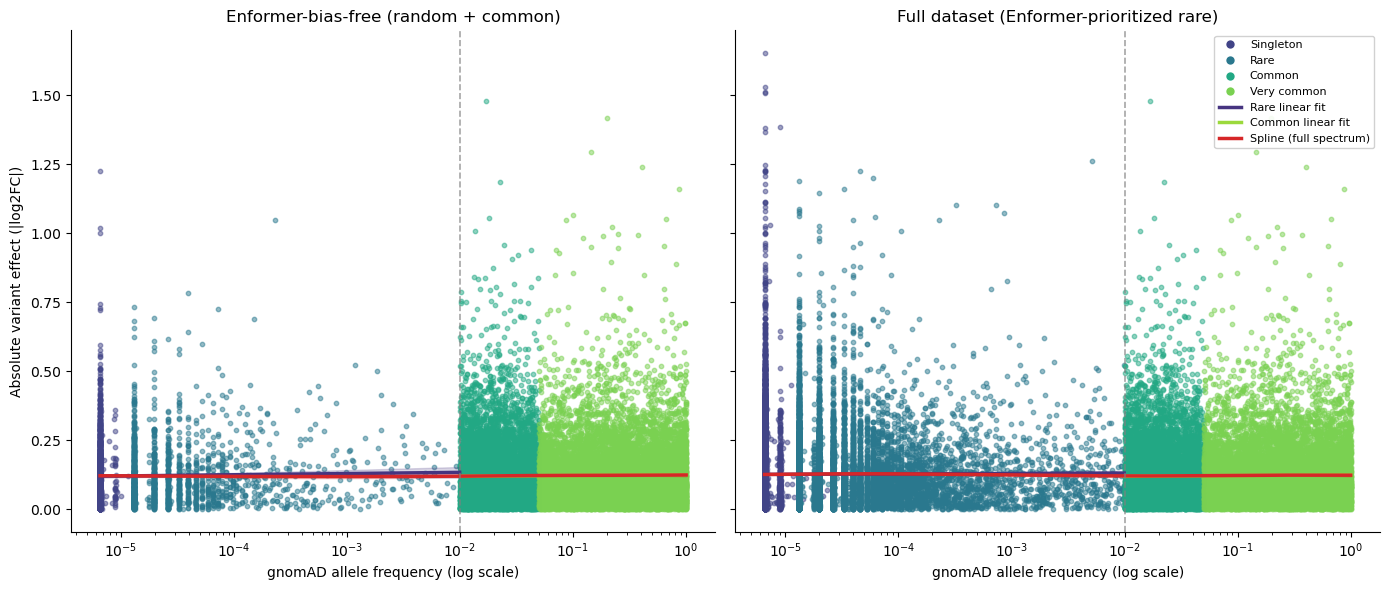


NUMBERS FOR THE MANUSCRIPT TEXT

Per-group linear regression on log10(AF):
  all_variants       rare_group   n= 20560  beta=+0.0014  p=0.361
  random_or_common   rare_group   n=  3092  beta=+0.0044  p=0.207
  all_variants       common_group n= 18124  beta=+0.0025  p=0.068

Rare-arm slope difference (full vs random): p = 0.433

Full-spectrum linear regression on log10(AF) (robustness):
  all_variants       n= 38684  beta=-0.0010  p=0.001
  random_or_common   n= 21216  beta=+0.0006  p=0.280
  Slope difference (full vs random): p = 0.010

Natural cubic spline vs linear (full spectrum):
  all_variants        F(3,38679) = 2.24, p = 0.082
  random_or_common    F(3,21211) = 0.51, p = 0.679


In [ ]:
def _spline_curve(res, n=300):
    xgrid = np.linspace(res["x_range"][0], res["x_range"][1], n)
    design_grid = build_design_matrices([res["design_info"]], {"x": xgrid, "knots": res["knots"]}, return_type="dataframe")[0]
    pred = res["spline_model"].get_prediction(sm.add_constant(design_grid, has_constant="add")).summary_frame(alpha=0.05)
    return xgrid, pred


def _scatter_with_fits(ax, df_panel, model_rare, model_common, s_rare, s_common, spline_res, category_colors, rare_color, common_color):
    for cat in CATEGORY_ORDER:
        m = df_panel["af_category"] == cat
        if m.sum():
            ax.scatter(df_panel.loc[m, "gnomad_AF"], df_panel.loc[m, "NGN2_variant_abs_logFC"],
                       c=[category_colors[cat]], alpha=0.5, s=10, rasterized=True)
    if model_rare is not None:
        df_rare = df_panel[df_panel["af_group"] == "rare_group"].copy()
        df_rare["log10_AF"] = np.log10(df_rare["gnomad_AF"])
        xr = np.linspace(df_rare["log10_AF"].min(), df_rare["log10_AF"].max(), 100)
        ax.plot(10 ** xr, model_rare.predict(sm.add_constant(xr)), color=rare_color, lw=2.5,
                label=f"Rare (beta={s_rare['slope']:.4f}, p={s_rare['p_value']:.2g})")
        pred = model_rare.get_prediction(sm.add_constant(xr)).summary_frame(alpha=0.05)
        ax.fill_between(10 ** xr, pred["mean_ci_lower"], pred["mean_ci_upper"], color=rare_color, alpha=0.2)
    if model_common is not None:
        df_c = df_panel[df_panel["af_group"] == "common_group"].copy()
        df_c["log10_AF"] = np.log10(df_c["gnomad_AF"])
        xc = np.linspace(df_c["log10_AF"].min(), df_c["log10_AF"].max(), 100)
        ax.plot(10 ** xc, model_common.predict(sm.add_constant(xc)), color=common_color, lw=2.5,
                label=f"Common (beta={s_common['slope']:.4f}, p={s_common['p_value']:.2g})")
        pred = model_common.get_prediction(sm.add_constant(xc)).summary_frame(alpha=0.05)
        ax.fill_between(10 ** xc, pred["mean_ci_lower"], pred["mean_ci_upper"], color=common_color, alpha=0.2)
    if spline_res is not None:
        xgrid, pred = _spline_curve(spline_res)
        ax.plot(10 ** xgrid, pred["mean"], color="C3", lw=2.5, label=f"Spline (F={spline_res['F']:.2f}, p={spline_res['p_F']:.2g})")
        ax.fill_between(10 ** xgrid, pred["mean_ci_lower"], pred["mean_ci_upper"], color="C3", alpha=0.15)
    ax.axvline(0.01, color="grey", ls="--", lw=1.2, alpha=0.7)
    ax.set_xscale("log")
    ax.set_xlabel("gnomAD allele frequency (log scale)")
    ax.spines[["top", "right"]].set_visible(False)


cmap = plt.cm.get_cmap(chosen_palette)
category_colors = dict(zip(CATEGORY_ORDER, sns.color_palette(chosen_palette, n_colors=4)))
rare_color, common_color = cmap(0.15), cmap(0.85)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
panels = [
    ("Enformer-bias-free (random + common)", df_random_or_common, m_rand_rare, m_rand_common, s_rand_rare, s_rand_common, spline_random),
    ("Full dataset (Enformer-prioritized rare)", df_full, m_full_rare, m_full_common, s_full_rare, s_full_common, spline_full),
]
for ax, (title, df_panel, mr, mc, sr, sc, sp) in zip(axes, panels):
    _scatter_with_fits(ax, df_panel, mr, mc, sr, sc, sp, category_colors, rare_color, common_color)
    ax.set_title(title)
axes[0].set_ylabel("Absolute variant effect (|log2FC|)")
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", label=c.capitalize(), markerfacecolor=category_colors[c],
               markeredgecolor="none", markersize=6)
    for c in CATEGORY_ORDER
]
handles += [
    plt.Line2D([0], [0], color=rare_color, lw=2.5, label="Rare linear fit"),
    plt.Line2D([0], [0], color=common_color, lw=2.5, label="Common linear fit"),
    plt.Line2D([0], [0], color="C3", lw=2.5, label="Spline (full spectrum)"),
]
axes[1].legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
plt.tight_layout()
if writing:
    out = os.path.join(base_figure_dir, "effect_vs_af_log10_dedup_spline")
    plt.savefig(out + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(out + ".svg", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 60)
print("NUMBERS FOR THE MANUSCRIPT TEXT")
print("=" * 60)
print("\nPer-group linear regression on log10(AF):")
for s in [s_full_rare, s_rand_rare, s_full_common]:
    print(f"  {s['dataset']:<18s} {s['af_group']:<12s} n={s['n_variants']:>6d}  beta={s['slope']:+.4f}  p={s['p_value']:.3f}")
print(f"\nRare-arm slope difference (full vs random): p = {p_diff_rare:.3f}")
print("\nFull-spectrum linear regression on log10(AF) (robustness):")
for s in [s_fs_full, s_fs_random]:
    print(f"  {s['dataset']:<18s} n={s['n_variants']:>6d}  beta={s['slope']:+.4f}  p={s['p_value']:.3f}")
print(f"  Slope difference (full vs random): p = {p_diff_fs:.3f}")
print("\nNatural cubic spline vs linear (full spectrum):")
for r in [spline_full, spline_random]:
    print(f"  {r['dataset']:<18s}  F({r['df_diff']:.0f},{r['df_full']:.0f}) = {r['F']:.2f}, p = {r['p_F']:.3f}")

## Why does a naive full-spectrum fit disagree with the within-group fits? (Simpson's paradox)

The full dataset's overall (rare+common pooled) slope looks negative, but within each
group separately the slope is close to flat. This resolves the apparent conflict: it's a
level shift (Enformer-prioritized rare variants have systematically higher mean effects
than common variants), not a genuine within-group AF-effect relationship.

/tmp/ipykernel_90927/4225460479.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(chosen_palette)


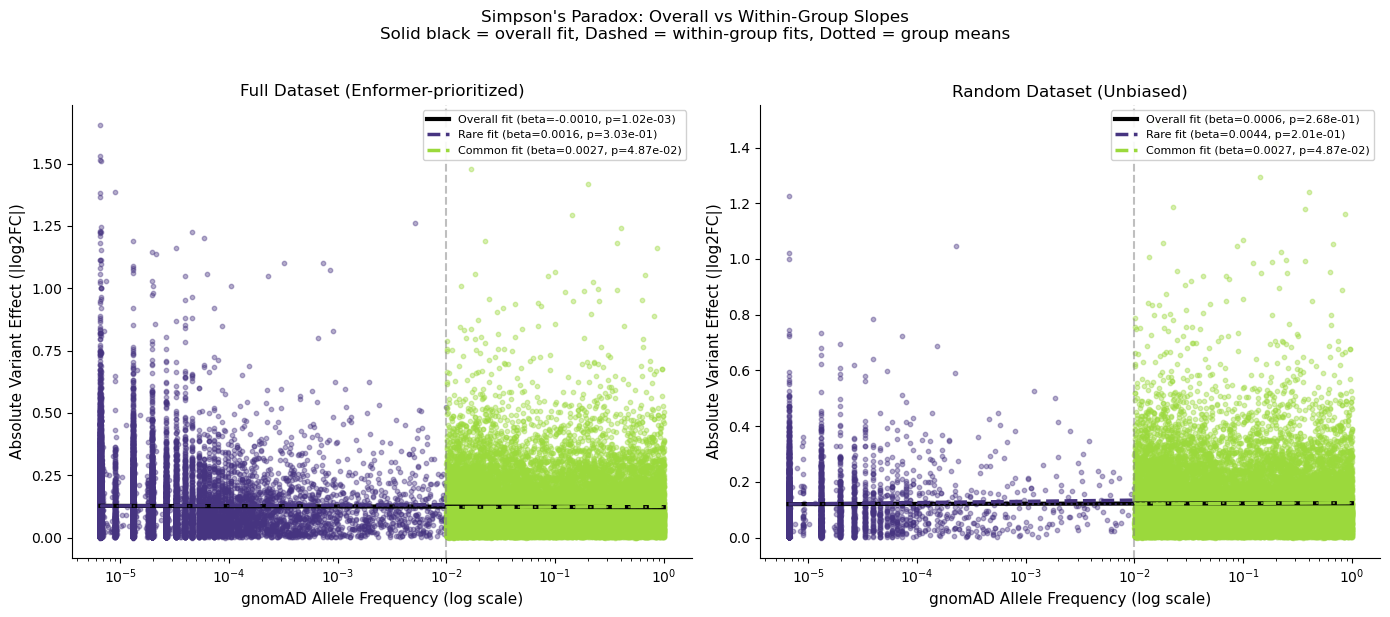

GROUP MEAN COMPARISON (explains Simpson's Paradox)

Full dataset:
  Rare group:   mean = 0.1272, n = 20717
  Common group: mean = 0.1222, n = 18251
  Difference:   0.0051
  T-test:       t = 4.124, p = 3.7338e-05

Enformer-bias-free dataset:
  Rare group:   mean = 0.1218, n = 3114
  Common group: mean = 0.1222, n = 18251
  Difference:   -0.0003
  T-test:       t = -0.142, p = 8.8688e-01

INTERPRETATION
The negative overall slope in the full dataset is a Simpson's Paradox:
1. WITHIN rare variants: no significant AF-effect relationship
2. WITHIN common variants: no significant AF-effect relationship
3. BUT: Enformer-prioritized rare variants have higher mean effects than common variants
4. This level shift creates an artificial negative slope when fitting across both groups

There is no evidence for a within-frequency-class AF-effect relationship; the apparent
full-spectrum relationship is driven by Enformer prioritization bias in which rare
variants were selected for testing.



In [ ]:
def visualize_simpsons_paradox(df_full, df_random, chosen_palette="viridis"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    cmap = plt.cm.get_cmap(chosen_palette)
    rare_color, common_color, overall_color = cmap(0.15), cmap(0.85), "black"

    for idx, (df, title) in enumerate(
        [(df_full, "Full Dataset (Enformer-prioritized)"), (df_random, "Random Dataset (Unbiased)")]
    ):
        ax = axes[idx]
        df = df.dropna(subset=["gnomad_AF", "NGN2_variant_abs_logFC"])
        df = df[df["gnomad_AF"] > 0].copy()
        df["log10_AF"] = np.log10(df["gnomad_AF"])
        df["af_group"] = df["af_category"].apply(lambda x: "rare_group" if x in ["singleton", "rare"] else "common_group")

        for group, color in [("rare_group", rare_color), ("common_group", common_color)]:
            mask = df["af_group"] == group
            ax.scatter(df.loc[mask, "gnomad_AF"], df.loc[mask, "NGN2_variant_abs_logFC"], c=[color], alpha=0.4, s=10, rasterized=True)

        model_all = sm.OLS(df["NGN2_variant_abs_logFC"], sm.add_constant(df["log10_AF"])).fit()
        x_range_all = np.linspace(df["log10_AF"].min(), df["log10_AF"].max(), 100)
        slope_all, p_all = model_all.params["log10_AF"], model_all.pvalues["log10_AF"]
        ax.plot(10 ** x_range_all, model_all.predict(sm.add_constant(x_range_all)), color=overall_color, linewidth=3,
                label=f"Overall fit (beta={slope_all:.4f}, p={p_all:.2e})")

        for group, color in [("rare_group", rare_color), ("common_group", common_color)]:
            df_group = df[df["af_group"] == group]
            if len(df_group) > 10:
                model_group = sm.OLS(df_group["NGN2_variant_abs_logFC"], sm.add_constant(df_group["log10_AF"])).fit()
                x_range = np.linspace(df_group["log10_AF"].min(), df_group["log10_AF"].max(), 100)
                slope, p = model_group.params["log10_AF"], model_group.pvalues["log10_AF"]
                group_label = "Rare" if group == "rare_group" else "Common"
                ax.plot(10 ** x_range, model_group.predict(sm.add_constant(x_range)), color=color, linewidth=2.5,
                        linestyle="--", label=f"{group_label} fit (beta={slope:.4f}, p={p:.2e})")

        for group, color in [("rare_group", rare_color), ("common_group", common_color)]:
            mean_effect = df[df["af_group"] == group]["NGN2_variant_abs_logFC"].mean()
            af_range = df[df["af_group"] == group]["gnomad_AF"]
            ax.hlines(mean_effect, af_range.min(), af_range.max(), colors=color, linestyles=":", linewidth=1.5, alpha=0.7)

        ax.axvline(x=0.01, color="grey", linestyle="--", linewidth=1.5, alpha=0.5)
        ax.set_xscale("log")
        ax.set_xlabel("gnomAD Allele Frequency (log scale)", fontsize=11)
        ax.set_ylabel("Absolute Variant Effect (|log2FC|)", fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(
        "Simpson's Paradox: Overall vs Within-Group Slopes\n"
        "Solid black = overall fit, Dashed = within-group fits, Dotted = group means",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    if writing:
        out = os.path.join(base_figure_dir, "simpsons_paradox_visualization")
        plt.savefig(out + ".png", dpi=300, bbox_inches="tight")
        plt.savefig(out + ".svg", dpi=300, bbox_inches="tight")
    plt.show()
    return fig, axes


visualize_simpsons_paradox(
    variant_effect_df_with_gnomad_activity_tested,
    variant_effect_df_with_gnomad_activity_tested_random_or_common,
    chosen_palette=chosen_palette,
)

print("=" * 60)
print("GROUP MEAN COMPARISON (explains Simpson's Paradox)")
print("=" * 60)
for dataset_name, dataset in [
    ("Full dataset", variant_effect_df_with_gnomad_activity_tested),
    ("Enformer-bias-free dataset", variant_effect_df_with_gnomad_activity_tested_random_or_common),
]:
    dataset = dataset.copy()
    dataset["af_group"] = dataset["af_category"].apply(lambda x: "rare_group" if x in ["singleton", "rare"] else "common_group")
    rare_effects = dataset[dataset["af_group"] == "rare_group"]["NGN2_variant_abs_logFC"]
    common_effects = dataset[dataset["af_group"] == "common_group"]["NGN2_variant_abs_logFC"]
    t_stat, p_ttest = stats.ttest_ind(rare_effects, common_effects)
    print(f"\n{dataset_name}:")
    print(f"  Rare group:   mean = {rare_effects.mean():.4f}, n = {len(rare_effects)}")
    print(f"  Common group: mean = {common_effects.mean():.4f}, n = {len(common_effects)}")
    print(f"  Difference:   {rare_effects.mean() - common_effects.mean():.4f}")
    print(f"  T-test:       t = {t_stat:.3f}, p = {p_ttest:.4e}")

print(
    "\n"
    + "=" * 60
    + "\nINTERPRETATION\n"
    + "=" * 60
    + """
The negative overall slope in the full dataset is a Simpson's Paradox:
1. WITHIN rare variants: no significant AF-effect relationship
2. WITHIN common variants: no significant AF-effect relationship
3. BUT: Enformer-prioritized rare variants have higher mean effects than common variants
4. This level shift creates an artificial negative slope when fitting across both groups

There is no evidence for a within-frequency-class AF-effect relationship; the apparent
full-spectrum relationship is driven by Enformer prioritization bias in which rare
variants were selected for testing.
"""
)

#### 

=== Linear Regression Summary (Separate fits for rare and common) ===
         dataset     af_group  n_variants    slope  intercept  r_squared  p_value  std_err  slope_ci_lower  slope_ci_upper
    all_variants   rare_group       20717 0.001572   0.134762   0.000051 0.302564 0.001525       -0.001417        0.004562
    all_variants common_group       18251 0.002734   0.125173   0.000213 0.048703 0.001387        0.000016        0.005452
random_or_common   rare_group        3114 0.004421   0.142977   0.000525 0.201074 0.003457       -0.002358        0.011199
random_or_common common_group       18251 0.002734   0.125173   0.000213 0.048703 0.001387        0.000016        0.005452

Interpretation: Negative slope = lower AF variants have larger effects within group

COMPARISON OF RARE VARIANT SLOPES

Full dataset (Enformer-prioritized):
  n = 20717
  slope = 0.001572 ± 0.001525
  p-value = 3.0256e-01

Random dataset (unbiased):
  n = 3114
  slope = 0.004421 ± 0.003457
  p-value = 2.0107e-01


/tmp/ipykernel_90927/2047692741.py:333: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(chosen_palette)


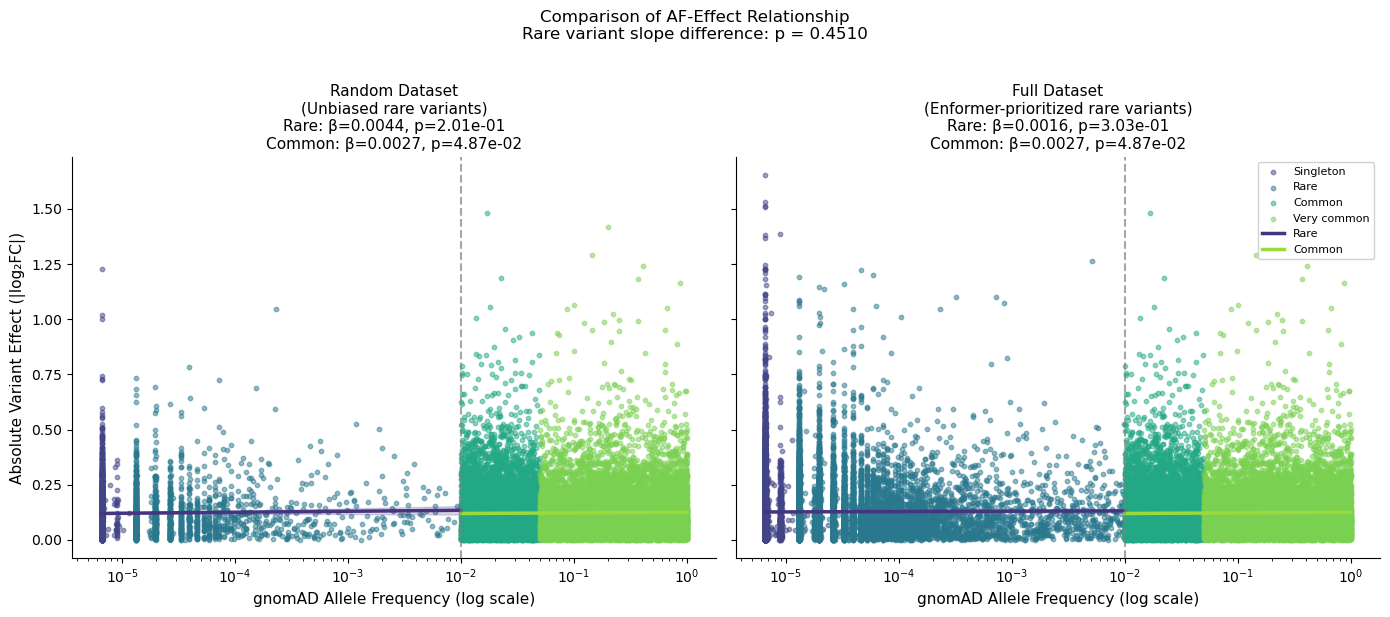


SUMMARY AND DECISION

Rare variant slopes:
  Random (unbiased): β = 0.0044, p = 0.2011
  Full (biased):     β = 0.0016, p = 0.3026
  Difference test:   p = 0.4510

→ Rare variant slopes are NOT significantly different
→ Enformer prioritization does not substantially bias the relationship
→ Can use full dataset for direction analysis

Common variant slope: β = 0.0027, p = 0.0487


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# =============================================================================
# SETUP
# =============================================================================


def assign_af_group(af_category):
    """Assign variants to 'rare' or 'common' group."""
    if af_category in ["singleton", "rare"]:
        return "rare_group"
    elif af_category in ["common", "very common"]:
        return "common_group"
    else:
        return "unknown"


# Add af_group to both datasets
variant_effect_df_with_gnomad_activity_tested["af_group"] = (
    variant_effect_df_with_gnomad_activity_tested["af_category"].apply(assign_af_group)
)

variant_effect_df_with_gnomad_activity_tested_random_or_common["af_group"] = (
    variant_effect_df_with_gnomad_activity_tested_random_or_common["af_category"].apply(
        assign_af_group
    )
)

# =============================================================================
# PART 1: Fit separate regressions for rare and common groups
# =============================================================================


def fit_group_regression(df, af_group, dataset_name):
    """
    Fit linear regression: abs_effect ~ log10(AF) for a specific AF group.
    """
    df_subset = df[df["af_group"] == af_group].copy()
    df_subset = df_subset.dropna(subset=["gnomad_AF", "NGN2_variant_abs_logFC"])
    df_subset = df_subset[df_subset["gnomad_AF"] > 0]

    if len(df_subset) < 10:
        print(
            f"Warning: Too few variants for {af_group} in {dataset_name} (n={len(df_subset)})"
        )
        return None, None, None

    df_subset["log10_AF"] = np.log10(df_subset["gnomad_AF"])

    X = sm.add_constant(df_subset["log10_AF"])
    y = df_subset["NGN2_variant_abs_logFC"]
    model = sm.OLS(y, X).fit()

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        df_subset["log10_AF"], df_subset["NGN2_variant_abs_logFC"]
    )

    summary = {
        "dataset": dataset_name,
        "af_group": af_group,
        "n_variants": len(df_subset),
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_value**2,
        "p_value": p_value,
        "std_err": std_err,
        "slope_ci_lower": model.conf_int().loc["log10_AF", 0],
        "slope_ci_upper": model.conf_int().loc["log10_AF", 1],
    }

    return model, summary, df_subset


# Fit all combinations
results = []

# Full dataset - rare
model_full_rare, summary_full_rare, df_full_rare = fit_group_regression(
    variant_effect_df_with_gnomad_activity_tested, "rare_group", "all_variants"
)
if summary_full_rare:
    results.append(summary_full_rare)

# Full dataset - common
model_full_common, summary_full_common, df_full_common = fit_group_regression(
    variant_effect_df_with_gnomad_activity_tested, "common_group", "all_variants"
)
if summary_full_common:
    results.append(summary_full_common)

# Random dataset - rare
model_random_rare, summary_random_rare, df_random_rare = fit_group_regression(
    variant_effect_df_with_gnomad_activity_tested_random_or_common,
    "rare_group",
    "random_or_common",
)
if summary_random_rare:
    results.append(summary_random_rare)

# Random dataset - common (should be identical to full)
model_random_common, summary_random_common, df_random_common = fit_group_regression(
    variant_effect_df_with_gnomad_activity_tested_random_or_common,
    "common_group",
    "random_or_common",
)
if summary_random_common:
    results.append(summary_random_common)

# Summary table
regression_summary = pd.DataFrame(results)
print("=== Linear Regression Summary (Separate fits for rare and common) ===")
print(regression_summary.to_string(index=False))
print(
    "\nInterpretation: Negative slope = lower AF variants have larger effects within group"
)

# =============================================================================
# PART 2: Compare rare variant slopes between datasets
# =============================================================================

print("\n" + "=" * 60)
print("COMPARISON OF RARE VARIANT SLOPES")
print("=" * 60)

if summary_full_rare and summary_random_rare:
    print(f"\nFull dataset (Enformer-prioritized):")
    print(f"  n = {summary_full_rare['n_variants']}")
    print(
        f"  slope = {summary_full_rare['slope']:.6f} ± {summary_full_rare['std_err']:.6f}"
    )
    print(f"  p-value = {summary_full_rare['p_value']:.4e}")

    print(f"\nRandom dataset (unbiased):")
    print(f"  n = {summary_random_rare['n_variants']}")
    print(
        f"  slope = {summary_random_rare['slope']:.6f} ± {summary_random_rare['std_err']:.6f}"
    )
    print(f"  p-value = {summary_random_rare['p_value']:.4e}")

    # Z-test for slope difference
    z_stat = (summary_full_rare["slope"] - summary_random_rare["slope"]) / np.sqrt(
        summary_full_rare["std_err"] ** 2 + summary_random_rare["std_err"] ** 2
    )
    p_diff_rare = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    print(f"\nZ-test for slope difference:")
    print(f"  z = {z_stat:.3f}, p = {p_diff_rare:.4f}")

    if p_diff_rare > 0.05:
        print("  → Slopes are NOT significantly different")
        enformer_bias_significant = False
    else:
        print("  → Slopes ARE significantly different")
        print("  → Enformer prioritization likely biases the rare variant relationship")
        enformer_bias_significant = True

# Verify common variants are identical
print("\n" + "=" * 60)
print("VERIFICATION: Common variant slopes (should be identical)")
print("=" * 60)
if summary_full_common and summary_random_common:
    print(
        f"Full dataset:   slope = {summary_full_common['slope']:.6f}, n = {summary_full_common['n_variants']}"
    )
    print(
        f"Random dataset: slope = {summary_random_common['slope']:.6f}, n = {summary_random_common['n_variants']}"
    )

# =============================================================================
# PART 3: Visualization
# =============================================================================


def plot_scatter_with_separate_fits(
    df_rare,
    df_common,
    model_rare,
    model_common,
    summary_rare,
    summary_common,
    title,
    chosen_palette="viridis",
    figsize=(10, 7),
    output_path=None,
):
    """
    Create scatter plot with separate regression lines for rare and common groups.
    """
    fig, ax = plt.subplots(figsize=figsize)

    cmap = plt.cm.get_cmap(chosen_palette)

    # Define colors for 4 categories
    category_colors = {
        "Singleton": cmap(0.0),
        "Rare": cmap(0.33),
        "Common": cmap(0.66),
        "Very Common": cmap(1.0),
    }

    rare_color = cmap(0.15)
    common_color = cmap(0.85)

    # Get the colors Seaborn assigns for your categories
    colors = sns.color_palette(chosen_palette, n_colors=len(category_colors))
    category_colors = dict(zip(category_order, colors))
    category_colors


    # Combine data for plotting
    df_all = pd.concat([df_rare, df_common], ignore_index=True)

    # Scatter plot with 4 category colors
    for cat in ["singleton", "rare", "common", "very common"]:
        mask = df_all["af_category"] == cat
        if mask.sum() > 0:
            ax.scatter(
                df_all.loc[mask, "gnomad_AF"],
                df_all.loc[mask, "NGN2_variant_abs_logFC"],
                c=[category_colors[cat]],
                alpha=0.5,
                s=12,
                label=cat.capitalize(),
                rasterized=True,
            )

    # Plot rare group regression line
    if model_rare is not None and df_rare is not None:
        x_range = np.linspace(df_rare["log10_AF"].min(), df_rare["log10_AF"].max(), 100)
        y_pred = model_rare.predict(sm.add_constant(x_range))
        ax.plot(
            10**x_range,
            y_pred,
            color=rare_color,
            linestyle="-",
            linewidth=2.5,
            label=f"Rare fit (β={summary_rare['slope']:.4f}, p={summary_rare['p_value']:.2e})",
        )
        # Confidence interval
        predictions = model_rare.get_prediction(sm.add_constant(x_range))
        pred_summary = predictions.summary_frame(alpha=0.05)
        ax.fill_between(
            10**x_range,
            pred_summary["mean_ci_lower"],
            pred_summary["mean_ci_upper"],
            color=rare_color,
            alpha=0.2,
        )

    # Plot common group regression line
    if model_common is not None and df_common is not None:
        x_range = np.linspace(
            df_common["log10_AF"].min(), df_common["log10_AF"].max(), 100
        )
        y_pred = model_common.predict(sm.add_constant(x_range))
        ax.plot(
            10**x_range,
            y_pred,
            color=common_color,
            linestyle="-",
            linewidth=2.5,
            label=f"Common fit (β={summary_common['slope']:.4f}, p={summary_common['p_value']:.2e})",
        )
        # Confidence interval
        predictions = model_common.get_prediction(sm.add_constant(x_range))
        pred_summary = predictions.summary_frame(alpha=0.05)
        ax.fill_between(
            10**x_range,
            pred_summary["mean_ci_lower"],
            pred_summary["mean_ci_upper"],
            color=common_color,
            alpha=0.2,
        )

    # Vertical line at AF = 1%
    ax.axvline(x=0.01, color="grey", linestyle="--", linewidth=1.5, alpha=0.7)

    ax.set_xscale("log")
    ax.set_xlabel("gnomAD Allele Frequency (log scale)", fontsize=12)
    ax.set_ylabel("Absolute Variant Effect (|log₂FC|)", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if output_path:
        plt.savefig(output_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight")
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()
    return fig, ax


# # Plot 1: Random dataset (unbiased rare variants)
# fig1, ax1 = plot_scatter_with_separate_fits(
#     df_random_rare,
#     df_random_common,
#     model_random_rare,
#     model_random_common,
#     summary_random_rare,
#     summary_random_common,
#     title="Variant Effect vs Allele Frequency\n(Randomly sampled rare + all common variants)",
#     chosen_palette=chosen_palette,
#     output_path=None,
# )

# # Plot 2: Full dataset (Enformer-prioritized rare variants)
# fig2, ax2 = plot_scatter_with_separate_fits(
#     df_full_rare,
#     df_full_common,
#     model_full_rare,
#     model_full_common,
#     summary_full_rare,
#     summary_full_common,
#     title="Variant Effect vs Allele Frequency\n(All variants including Enformer-prioritized)",
#     chosen_palette=chosen_palette,
#     output_path=None,
# )

# =============================================================================
# PART 4: Side-by-side comparison figure
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

cmap = plt.cm.get_cmap(chosen_palette)
category_colors = {
    "Singleton": cmap(0.0),
    "Rare": cmap(0.33),
    "Common": cmap(0.66),
    "Very Common": cmap(1.0),
}
# Get the colors Seaborn assigns for your categories
colors = sns.color_palette("viridis", n_colors=len(category_colors))
category_colors = dict(zip(category_order, colors))
category_colors

rare_color = cmap(0.15)
common_color = cmap(0.85)

datasets = [
    (
        "Random Dataset\n(Unbiased rare variants)",
        df_random_rare,
        df_random_common,
        model_random_rare,
        model_random_common,
        summary_random_rare,
        summary_random_common,
    ),
    (
        "Full Dataset\n(Enformer-prioritized rare variants)",
        df_full_rare,
        df_full_common,
        model_full_rare,
        model_full_common,
        summary_full_rare,
        summary_full_common,
    ),
]

for idx, (title, df_rare, df_common, m_rare, m_common, s_rare, s_common) in enumerate(
    datasets
):
    ax = axes[idx]

    df_all = pd.concat([df_rare, df_common], ignore_index=True)

    # Scatter
    for cat in ["singleton", "rare", "common", "very common"]:
        mask = df_all["af_category"] == cat
        if mask.sum() > 0:
            ax.scatter(
                df_all.loc[mask, "gnomad_AF"],
                df_all.loc[mask, "NGN2_variant_abs_logFC"],
                c=[category_colors[cat]],
                alpha=0.5,
                s=10,
                label=cat.capitalize() if idx == 1 else None,
                rasterized=True,
            )

    # Rare fit
    if m_rare is not None:
        x_range = np.linspace(df_rare["log10_AF"].min(), df_rare["log10_AF"].max(), 100)
        y_pred = m_rare.predict(sm.add_constant(x_range))
        ax.plot(
            10**x_range,
            y_pred,
            color=rare_color,
            linewidth=2.5,
            label=(
                f"Rare"
                if idx == 1
                else None
            ),
        )
        pred = m_rare.get_prediction(sm.add_constant(x_range)).summary_frame(alpha=0.05)
        ax.fill_between(
            10**x_range,
            pred["mean_ci_lower"],
            pred["mean_ci_upper"],
            color=rare_color,
            alpha=0.2,
        )

    # Common fit
    if m_common is not None:
        x_range = np.linspace(
            df_common["log10_AF"].min(), df_common["log10_AF"].max(), 100
        )
        y_pred = m_common.predict(sm.add_constant(x_range))
        ax.plot(
            10**x_range,
            y_pred,
            color=common_color,
            linewidth=2.5,
            label=(
                f"Common"
                if idx == 1
                else None
            ),
        )
        pred = m_common.get_prediction(sm.add_constant(x_range)).summary_frame(
            alpha=0.05
        )
        ax.fill_between(
            10**x_range,
            pred["mean_ci_lower"],
            pred["mean_ci_upper"],
            color=common_color,
            alpha=0.2,
        )

    ax.axvline(x=0.01, color="grey", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_xscale("log")
    ax.set_xlabel("gnomAD Allele Frequency (log scale)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Absolute Variant Effect (|log₂FC|)", fontsize=11)

    # Add slope info to title
    rare_info = (
        f"Rare: β={s_rare['slope']:.4f}, p={s_rare['p_value']:.2e}"
        if s_rare
        else "Rare: N/A"
    )
    common_info = (
        f"Common: β={s_common['slope']:.4f}, p={s_common['p_value']:.2e}"
        if s_common
        else "Common: N/A"
    )
    ax.set_title(f"{title}\n{rare_info}\n{common_info}", fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].legend(loc="upper right", fontsize=8, framealpha=0.9)

# Add slope comparison to suptitle
suptitle = f"Comparison of AF-Effect Relationship\nRare variant slope difference: p = {p_diff_rare:.4f}"
plt.suptitle(suptitle, fontsize=12, y=1.02)
plt.tight_layout()

if writing:
    plt.savefig(
        "data/effect_vs_af_comparison_separate_fits.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        "data/effect_vs_af_comparison_separate_fits.svg",
        dpi=300,
        bbox_inches="tight",
    )
plt.show()

# =============================================================================
# PART 5: Decision and next steps
# =============================================================================

print("\n" + "=" * 60)
print("SUMMARY AND DECISION")
print("=" * 60)

print("\nRare variant slopes:")
print(
    f"  Random (unbiased): β = {summary_random_rare['slope']:.4f}, p = {summary_random_rare['p_value']:.4f}"
)
print(
    f"  Full (biased):     β = {summary_full_rare['slope']:.4f}, p = {summary_full_rare['p_value']:.4f}"
)
print(f"  Difference test:   p = {p_diff_rare:.4f}")

if p_diff_rare > 0.05:
    print("\n→ Rare variant slopes are NOT significantly different")
    print("→ Enformer prioritization does not substantially bias the relationship")
    print("→ Can use full dataset for direction analysis")
    use_full_for_direction = True
else:
    print("\n→ Rare variant slopes ARE significantly different")
    print("→ Enformer prioritization likely introduces bias")
    print(
        "→ Should use random dataset for direction analysis (but may have limited power)"
    )
    use_full_for_direction = False

print(
    f"\nCommon variant slope: β = {summary_full_common['slope']:.4f}, p = {summary_full_common['p_value']:.4f}"
)

In [ ]:
# Print the number of variants with readout
print(
    f"Number of variants with readout: {variant_effect_df_with_gnomad_activity_tested.shape[0]}"
)

print(
    f"Proportion of significant variants in active regions: {variant_effect_df_with_gnomad_activity_tested['NGN2_variant_adj_p-value'].lt(significant_threshold).mean()*100:.2f}%"
)

Number of variants with readout: 38968
Proportion of significant variants in active regions: 2.61%


In [ ]:
plot_directory = "/home/kisa/coding/80K_MPRA/reference_variant_relation"

# For plotting the pos neg proportions per binned column
def plot_binned_columns_significants_ratios_pos_neg_updated(
    variant_effect_df,
    column_name,
    x_label,
    y_label,
    plot_title,
    storing=False,
    name_addition="",
    variant_effect_col="NGN2_variant_logFC",
    variant_effect_pval_col="NGN2_variant_adj_p-value",
    significant_threshold=0.1,
    ylim_min=0,
    ylim_max=1,
    pos_color="tab:blue",
    neg_color="tab:red",
    equidistant_bins=True,
    too_small_annotations_expected=False,
    percent_annotation_fontsize=14,
    count_annotation_fontsize=13,
    axis_label_fontsize=14,
    title_fontsize=15,
    tick_label_fontsize=12,
):

    # --------------------------
    # 1. Create significance & effect direction columns
    # --------------------------
    variant_effect_df = variant_effect_df.copy()

    variant_effect_df["is_significant_plot"] = np.where(
        variant_effect_df[variant_effect_pval_col] < significant_threshold, "yes", "no"
    )
    variant_effect_df["effect_direction_plot"] = np.where(
        variant_effect_df[variant_effect_col] > 0, "pos", "neg"
    )

    # --------------------------
    # 2. Create bins
    # --------------------------
    if equidistant_bins:
        # equidistant bins
        min_value_seq = variant_effect_df[column_name].min()
        max_value_seq = variant_effect_df[column_name].max()

        # Define the number of bins
        num_bins_seq = 10

        # Prepare bin edges
        bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

        # Prepare bin labels
        bin_labels_seq = [
            f"{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}"
            for i in range(len(bin_edges_seq) - 1)
        ]

        # Create bins for column_name with specified labels
        variant_effect_df[column_name + "_bin"] = pd.cut(
            variant_effect_df[column_name],
            bins=bin_edges_seq,
            labels=bin_labels_seq,
            include_lowest=True,
        )
    else:
        # quantile bins
        num_bins_seq = 10
        variant_effect_df[column_name + "_bin"] = pd.qcut(
            variant_effect_df[column_name], q=num_bins_seq, duplicates="drop"
        )
    # --------------------------
    # 3. Count significant/non-significant
    # --------------------------
    bin_counts = (
        variant_effect_df.groupby([column_name + "_bin", "is_significant_plot"])
        .size()
        .unstack(fill_value=0)
        .rename_axis(None, axis=1)
        .reset_index()
    )

    # total variants per bin
    bin_counts["total"] = bin_counts["yes"] + bin_counts["no"]
    bin_counts["ratio_significant"] = bin_counts["yes"] / bin_counts["total"]

    # --------------------------
    # 4. Count pos/neg among significant only
    # --------------------------
    sig_df = variant_effect_df[variant_effect_df["is_significant_plot"] == "yes"]

    posneg = (
        sig_df.groupby([column_name + "_bin", "effect_direction_plot"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .rename_axis(None, axis=1)
    )

    # merge
    merged = bin_counts.merge(posneg, on=f"{column_name}_bin", how="left")
    merged["pos"] = merged.get("pos", 0)
    merged["neg"] = merged.get("neg", 0)

    # --------------------------
    # 5. Compute stacked bar heights
    # --------------------------
    merged["pos_frac"] = merged["pos"] / merged["total"]
    merged["neg_frac"] = merged["neg"] / merged["total"]

    # stack sums must equal ratio_significant
    # (pos_frac + neg_frac = ratio_significant)

    # --------------------------
    # 6. Plot
    # --------------------------
    # Reset to default style BEFORE creating the figure/axes, since spine
    # linewidth is fixed at axes-creation time and a reset issued afterward
    # (as in the previous version) only takes effect on the next plot.
    plt.style.use("default")

    plt.figure(figsize=(12, 6))

    x = np.arange(len(merged))

    plt.bar(
        x,
        merged["pos_frac"],
        color=pos_color,
        label="Increasing effect",
    )
    plt.bar(
        x,
        merged["neg_frac"],
        bottom=merged["pos_frac"],
        color=neg_color,
        label="Decreasing effect",
    )

    plt.xticks(
        x,
        merged[f"{column_name}_bin"].astype(str),
        rotation=45,
        ha="right",
        fontsize=tick_label_fontsize,
    )
    plt.yticks(fontsize=tick_label_fontsize)
    plt.ylim(ylim_min, ylim_max)
    plt.xlabel(x_label, fontsize=axis_label_fontsize)
    plt.ylabel(y_label, fontsize=axis_label_fontsize)
    plt.title(plot_title, fontsize=title_fontsize)
    plt.legend(fontsize=tick_label_fontsize)

    # --------------------------
    # Annotate fractions inside the stacks
    # --------------------------
    for i, row in merged.iterrows():

        # # If there are no significant variants, skip annotation
        # if row["yes"] == 0:
        #     continue

        # pos fraction among significant variants
        pos_frac_sig = row["pos"] / row["yes"] if row["yes"] > 0 else 0
        neg_frac_sig = row["neg"] / row["yes"] if row["yes"] > 0 else 0

        # positions for centered text
        pos_height = row["pos_frac"]
        neg_height = row["neg_frac"]

        # If the sum of the fraction is too small (<=0.05) only annotate the larger one
        if too_small_annotations_expected & ((pos_height + neg_height) <= 0.05):
            if pos_height >= neg_height:
                # annotate only pos
                neg_height = 0
            else:
                # annotate only neg
                pos_height = 0

        # annotate pos stack
        if pos_height > 0:
            plt.text(
                i,
                pos_height / 2,
                f"{pos_frac_sig*100:.1f}%",
                color="white",
                ha="center",
                va="center",
                fontsize=percent_annotation_fontsize,
                fontweight="bold",
            )

        # annotate neg stack (above pos)
        if neg_height > 0:
            plt.text(
                i,
                pos_height + neg_height / 2,
                f"{neg_frac_sig*100:.1f}%",
                color="white",
                ha="center",
                va="center",
                fontsize=percent_annotation_fontsize,
                fontweight="bold",
            )

        # annotate counts
        text = f"{row['yes']}/{row['total']}"
        plt.text(
            i,
            row["ratio_significant"],
            text,
            ha="center",
            va="bottom",
            fontsize=count_annotation_fontsize,
        )

    # White background
    plt.gcf().patch.set_facecolor("white")
    plt.gca().set_facecolor("white")

    # No borders around the plot at all
    for spine in plt.gca().spines.values():
        spine.set_visible(False)

    if storing:
        plt.savefig(
            os.path.join(
                plot_directory,
                f"stacked_posneg_ratio_{column_name}{name_addition}.png",
            ),
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()


/tmp/ipykernel_115850/443612098.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variant_effect_df.groupby([column_name + "_bin", "is_significant_plot"])
/tmp/ipykernel_115850/443612098.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig_df.groupby([column_name + "_bin", "effect_direction_plot"])


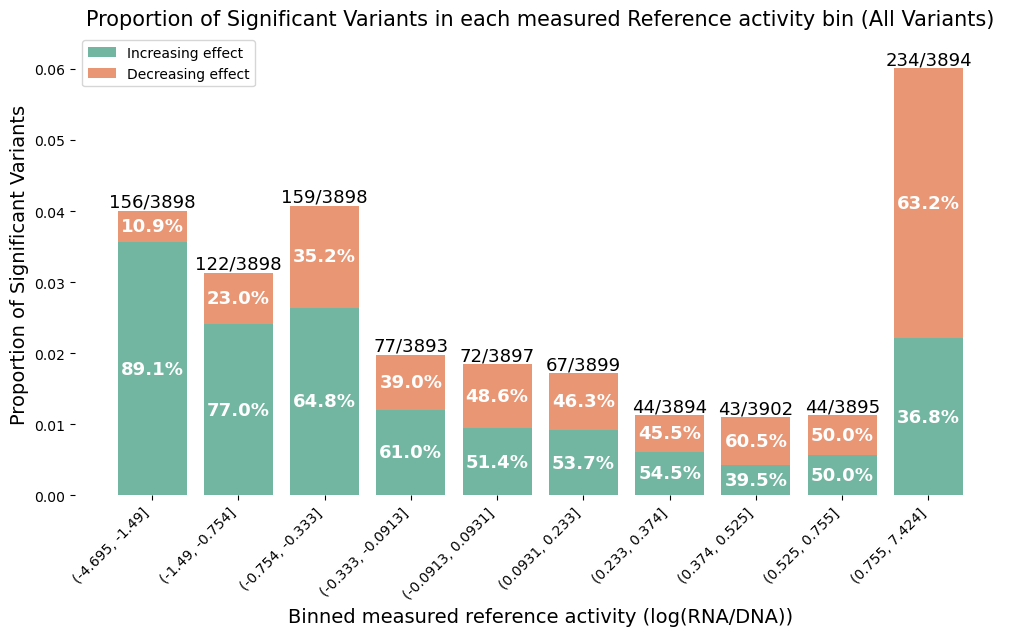

In [ ]:
effect_colors = {
    "decreasing": "#E99675",
    "increasing": "#72B6A1",
    "not_significant": "lightgray",
}
ylim_min=0
ylim_max=0.065
plot_binned_columns_significants_ratios_pos_neg_updated(
    variant_effect_df = variant_effect_df_with_gnomad_activity_tested.copy(),
    column_name="NGN2_region_normalized_activity",
    x_label="Binned measured reference activity (log(RNA/DNA))",
    y_label="Proportion of Significant Variants",
    plot_title="Proportion of Significant Variants in each measured Reference activity bin (All Variants)",
    storing=False,
    name_addition="_all_results_",
    variant_effect_col="NGN2_variant_logFC",
    variant_effect_pval_col="NGN2_variant_adj_p-value",
    significant_threshold=significant_threshold,
    ylim_min=ylim_min,
    ylim_max=ylim_max,
    pos_color=effect_colors["increasing"],
    neg_color=effect_colors["decreasing"],
    equidistant_bins=False,
    percent_annotation_fontsize=13,
    count_annotation_fontsize=13,
    axis_label_fontsize=14,
    title_fontsize=15,
    tick_label_fontsize=10,
)